In [2]:
from __future__ import annotations

import logging
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
from scipy import stats
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from rule_backtest.signals import SIGNAL_CLASSES, BaseSignal
from rule_backtest.data_loader import (
    load_cached_trades,
    merge_aggtrades,
    build_bars,
    compute_factor,
    estimate_avg_bar_seconds,
    RAW_FACTOR_REGISTRY,
    MERGED_FACTOR_REGISTRY,
)

logger = logging.getLogger(__name__)

In [3]:
cache_dir = Path("/Volumes/Lexar/mean_reversion_data/cache")

In [4]:
symbol='SOL/USDC'
cache_subdir: str = "trades_perp"
sym_dir = cache_dir / symbol.replace("/", "_") / cache_subdir
if not sym_dir.exists():
    raise FileNotFoundError(f"Cache directory not found: {sym_dir}")

start_date = '2026-02-02'
end_date = '2026-03-04'
files = sorted(f for f in sym_dir.glob("*.parquet") if not f.name.startswith("._") and start_date <= f.stem <= end_date)

if not files:
    raise FileNotFoundError(f"No parquet files in {sym_dir}")

logger.info("Loading %d cached files from %s", len(files), sym_dir)
dfs = [pd.read_parquet(f) for f in files]
trades = pd.concat(dfs, ignore_index=True)
trades["timestamp"] = pd.to_datetime(trades["timestamp"])
trades.sort_values("timestamp", inplace=True)
trades.reset_index(drop=True, inplace=True)

# Unified column names
trades.rename(columns={"amount": "volume", "cost": "value"}, inplace=True)

logger.info("Loaded %d trades, %s → %s",
            len(trades), trades["timestamp"].iloc[0], trades["timestamp"].iloc[-1])

In [5]:
trades_df = merge_aggtrades(trades)
trades_df.head()

,timestamp,volume,side,value,n_fills,n_raw_trades,first_price,last_price,first_trade_id,last_trade_id,price,price_range
0,2026-02-02 16:00:01.690000+00:00,16.45,sell,1720.3798,2,7,104.59,104.58,304094557,304094563,104.582359,0.01
1,2026-02-02 16:00:01.843000+00:00,40.10,buy,4193.8513,2,3,104.58,104.59,304094564,304094566,104.584820,0.01
2,2026-02-02 16:00:01.970000+00:00,62.43,sell,6528.9294,1,3,104.58,104.58,304094567,304094569,104.580000,0.00
3,2026-02-02 16:00:02.100000+00:00,5.02,sell,525.0418,1,3,104.59,104.59,304094570,304094572,104.590000,0.00
4,2026-02-02 16:00:02.360000+00:00,0.06,buy,6.2754,1,1,104.59,104.59,304094573,304094573,104.590000,0.00


In [ ]:
# Bar spec：与 build_bars 签名一致 — 第 4 个位置参数是 freq(str)，不是 tpb
bar_mode = "trade_count"
trades_per_bar = 200
bars = build_bars(trades_df, "merged", bar_mode, freq="1min", trades_per_bar=trades_per_bar)
bar_sec = int(estimate_avg_bar_seconds(bars))
logger.info("Built %d trade-count bars (tpb=%d, ~%ds avg)", len(bars), trades_per_bar, bar_sec)

## helper functions

In [6]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
from datetime import datetime

def calculate_trading_metrics(bars, position_col, returns_col, fee_rate, factor_name, fw, ema_w):
    """
    计算全面的交易绩效指标（修正版：正确处理反向交易）
    """
    
    # 基础数据准备
    df = bars.copy()
    
    # 计算原始收益（不含费用）
    df['raw_returns'] = df[position_col].shift(1) * df['returns']
    
    # 识别持仓变化
    df['position_prev'] = df[position_col].shift(1).fillna(0)
    df['position_change'] = df[position_col] - df['position_prev']
    
    # 初始化信号列
    df['open_signal'] = False
    df['close_signal'] = False
    
    # 识别开仓和平仓时刻（正确处理反向交易）
    for i in range(1, len(df)):
        change = df['position_change'].iloc[i]
        prev_pos = df['position_prev'].iloc[i]
        curr_pos = df[position_col].iloc[i]
        
        if change == 0:
            continue
        
        if abs(change) == 1:
            # 普通开仓或平仓
            if prev_pos == 0:  # 0 -> ±1，开仓
                df.loc[df.index[i], 'open_signal'] = True
            elif curr_pos == 0:  # ±1 -> 0，平仓
                df.loc[df.index[i], 'close_signal'] = True
                
        elif abs(change) == 2:
            # 反向交易：先平仓，再开仓
            # 平仓发生在 bar i 开盘（使用上一根 bar 的持仓）
            df.loc[df.index[i], 'close_signal'] = True
            # 开仓也发生在 bar i 开盘（新方向）
            df.loc[df.index[i], 'open_signal'] = True
    
    # 构建交易列表
    trades = []
    current_trade = None
    
    for i in range(len(df)):
        # 先处理平仓（如果有）
        if df['close_signal'].iloc[i] and current_trade is not None:
            # 平仓
            current_trade['exit_time'] = df.index[i]
            current_trade['exit_price'] = df['open'].iloc[i]  # 以开盘价平仓
            trades.append(current_trade)
            current_trade = None
        
        # 再处理开仓
        if df['open_signal'].iloc[i]:
            direction = df[position_col].iloc[i]  # 当前持仓方向
            current_trade = {
                'entry_time': df.index[i],
                'entry_price': df['open'].iloc[i],
                'direction': direction,
                'exit_time': None,
                'exit_price': None,
                'return_raw': 0,
                'bars_held': 0
            }
        
        # 更新当前持仓的收益
        if current_trade is not None:
            current_trade['return_raw'] += df['raw_returns'].iloc[i]
            current_trade['bars_held'] += 1
    
    # 处理最后一笔未平仓交易
    if current_trade is not None:
        trades.append(current_trade)
    
    # 转换为DataFrame
    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame()
    
    # 统计指标
    if not trades_df.empty:
        # 基本交易统计
        n_trades_total = len(trades_df)
        long_trades = trades_df[trades_df['direction'] == 1]
        short_trades = trades_df[trades_df['direction'] == -1]
        n_long = len(long_trades)
        n_short = len(short_trades)
        
        # 胜率计算
        win_rate_total = (trades_df['return_raw'] > 0).mean() * 100
        win_rate_long = (long_trades['return_raw'] > 0).mean() * 100 if n_long > 0 else 0
        win_rate_short = (short_trades['return_raw'] > 0).mean() * 100 if n_short > 0 else 0
        
        # 盈亏比相关
        winning_trades = trades_df[trades_df['return_raw'] > 0]
        losing_trades = trades_df[trades_df['return_raw'] < 0]
        
        avg_win = winning_trades['return_raw'].mean() if len(winning_trades) > 0 else 0
        avg_loss = losing_trades['return_raw'].mean() if len(losing_trades) > 0 else 0
        
        profit_factor = abs(avg_win * len(winning_trades) / (avg_loss * len(losing_trades))) if len(losing_trades) > 0 and avg_loss != 0 else float('inf')
        
        # 最大连续亏损
        trades_df['is_win'] = trades_df['return_raw'] > 0
        trades_df['consecutive_losses'] = (~trades_df['is_win']).groupby((trades_df['is_win'] != trades_df['is_win'].shift()).cumsum()).cumsum()
        max_consecutive_losses = trades_df['consecutive_losses'].max()
        
        # 平均持仓bar数
        avg_bars_held = trades_df['bars_held'].mean()
        
        # 最佳/最差交易
        best_trade = trades_df['return_raw'].max()
        worst_trade = trades_df['return_raw'].min()
        expectancy = trades_df['return_raw'].mean()
        
    else:
        n_trades_total = n_long = n_short = 0
        win_rate_total = win_rate_long = win_rate_short = 0
        profit_factor = 0
        max_consecutive_losses = 0
        avg_bars_held = 0
        best_trade = worst_trade = expectancy = 0
        avg_win = 0  # 添加这一行
        avg_loss = 0  # 添加这一行
        long_trades = short_trades = pd.DataFrame()
    
    # 累计收益（不含费用）
    df['cumulative_raw'] = (1 + df['raw_returns']).cumprod()
    df['cumulative_long_raw'] = (1 + df['raw_returns'] * (df[position_col] == 1).astype(int)).cumprod()
    df['cumulative_short_raw'] = (1 + df['raw_returns'] * (df[position_col] == -1).astype(int)).cumprod()
    
    # 累计收益（含费用）
    df['cumulative_net'] = (1 + df[returns_col]).cumprod()
    
    # 风险指标
    risk_free_rate = 0  # 0%年化无风险利率，分钟级数据
    
    # 夏普比率
    excess_returns = df[returns_col] - risk_free_rate
    sharpe_ratio = np.sqrt(len(df)) * excess_returns.mean() / excess_returns.std() if excess_returns.std() > 0 else 0
    
    # 最大回撤
    rolling_max = df['cumulative_net'].expanding().max()
    drawdown = (df['cumulative_net'] - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    max_drawdown_duration = (drawdown == 0).astype(int).groupby(drawdown.ne(0).astype(int).cumsum()).cumsum().max()
    
    # 卡尔玛比率
    calmar_ratio = (df['cumulative_net'].iloc[-1] - 1) / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # 费用统计
    total_fees = (fee_rate * df['position_change'].abs()).sum()
    avg_fee_per_trade = total_fees / n_trades_total if n_trades_total > 0 else 0
    
    # 反向交易统计（用于诊断）
    n_reversals = (df['position_change'].abs() == 2).sum()
    
    # 年化指标（假设分钟级数据）
    bars_per_year = 365 * 24 * 60
    total_return_net = df['cumulative_net'].iloc[-1] - 1
    annualized_return = (1 + total_return_net) ** (bars_per_year / len(df)) - 1
    annualized_volatility = df[returns_col].std() * np.sqrt(bars_per_year)
    
    # 收集所有指标
    metrics = {
        # 基本信息
        'factor_name': factor_name,
        'fw': fw,
        'ema_w': ema_w,
        'start_date': df.index[0],
        'end_date': df.index[-1],
        'total_bars': len(df),
        
        # 收益指标
        'total_return_net': total_return_net,
        'total_return_long_raw': df['cumulative_long_raw'].iloc[-1] - 1,
        'total_return_short_raw': df['cumulative_short_raw'].iloc[-1] - 1,
        'benchmark_return': df['benchmark_cumulative'].iloc[-1] - 1,
        'annualized_return': annualized_return,
        'annualized_volatility': annualized_volatility,
        
        # 交易统计
        'n_trades_total': n_trades_total,
        'n_long': n_long,
        'n_short': n_short,
        'n_reversals': n_reversals,
        'avg_bars_held': avg_bars_held,
        
        # 胜率
        'win_rate_total': win_rate_total,
        'win_rate_long': win_rate_long,
        'win_rate_short': win_rate_short,
        
        # 盈亏分析
        'profit_factor': profit_factor,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'expectancy': expectancy,
        'best_trade': best_trade,
        'worst_trade': worst_trade,
        'max_consecutive_losses': max_consecutive_losses,
        
        # 风险指标
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'max_drawdown_duration': max_drawdown_duration,
        'calmar_ratio': calmar_ratio,
        
        # 费用统计
        'total_fees': total_fees,
        'avg_fee_per_trade': avg_fee_per_trade,
        'fee_rate': fee_rate,
    }
    
    return metrics, trades_df, df


def print_metrics_summary(metrics):
    """打印指标汇总"""
    print("=" * 60)
    print(f"策略绩效报告 - {metrics['factor_name']} (fw={metrics['fw']}, ema={metrics['ema_w']})")
    print("=" * 60)
    print(f"回测期间: {metrics['start_date']} 至 {metrics['end_date']}")
    print(f"总Bar数: {metrics['total_bars']}")
    print("-" * 60)
    print("【收益指标】")
    print(f"  策略总收益 (净): {metrics['total_return_net']:.2%}")
    print(f"  多头收益 (原始): {metrics['total_return_long_raw']:.2%}")
    print(f"  空头收益 (原始): {metrics['total_return_short_raw']:.2%}")
    print(f"  基准收益: {metrics['benchmark_return']:.2%}")
    print(f"  年化收益率: {metrics['annualized_return']:.2%}")
    print("-" * 60)
    print("【交易统计】")
    print(f"  总交易次数: {metrics['n_trades_total']}")
    print(f"  多头交易: {metrics['n_long']}")
    print(f"  空头交易: {metrics['n_short']}")
    print(f"  反向交易: {metrics['n_reversals']}")
    print(f"  平均持仓Bar数: {metrics['avg_bars_held']:.2f}")
    print("-" * 60)
    print("【胜率统计】")
    print(f"  总胜率: {metrics['win_rate_total']:.2f}%")
    print(f"  多头胜率: {metrics['win_rate_long']:.2f}%")
    print(f"  空头胜率: {metrics['win_rate_short']:.2f}%")
    print("-" * 60)
    print("【盈亏分析】")
    print(f"  盈亏比 (Profit Factor): {metrics['profit_factor']:.3f}")
    print(f"  平均盈利: {metrics['avg_win']:.4%}")
    print(f"  平均亏损: {metrics['avg_loss']:.4%}")
    print(f"  单笔期望收益: {metrics['expectancy']:.4%}")
    print(f"  最佳交易: {metrics['best_trade']:.4%}")
    print(f"  最差交易: {metrics['worst_trade']:.4%}")
    print("-" * 60)
    print("【风险指标】")
    print(f"  夏普比率: {metrics['sharpe_ratio']:.3f}")
    print(f"  最大回撤: {metrics['max_drawdown']:.2%}")
    print(f"  最大回撤持续期 (bars): {metrics['max_drawdown_duration']}")
    print(f"  卡尔玛比率: {metrics['calmar_ratio']:.3f}")
    print(f"  年化波动率: {metrics['annualized_volatility']:.2%}")
    print("-" * 60)
    print("【费用统计】")
    print(f"  总手续费: {metrics['total_fees']:.6f}")
    print(f"  平均每笔手续费: {metrics['avg_fee_per_trade']:.6f}")
    print(f"  费率设置: {metrics['fee_rate']:.6f}")
    print("=" * 60)


def save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw, ema_w):
    """保存指标到文件"""
    # 创建输出目录
    save_dir = output_dir / factor_name / f"fw{fw}_ema{ema_w}" / "metrics"
    save_dir.mkdir(parents=True, exist_ok=True)
    
    # 保存指标摘要为JSON
    metrics_serializable = {k: (str(v) if isinstance(v, pd.Timestamp) else v) 
                           for k, v in metrics.items()}
    with open(save_dir / "metrics_summary.json", 'w') as f:
        json.dump(metrics_serializable, f, indent=4, default=str)
    
    # 保存交易明细为CSV
    if not trades_df.empty:
        trades_df.to_csv(save_dir / "trades_detail.csv")
    
    # 保存文本报告
    with open(save_dir / "report.txt", 'w') as f:
        # 重定向print输出到文件
        import sys
        original_stdout = sys.stdout
        sys.stdout = f
        print_metrics_summary(metrics)
        sys.stdout = original_stdout


def plot_enhanced_results(bars, metrics, trades_df, factor_name, fw, ema_w, output_dir):
    """绘制增强版结果图表"""
    
    # 创建3行图表
    fig = make_subplots(
        rows=3, cols=2,
        shared_xaxes=True,
        subplot_titles=('累计收益对比', '策略 vs 基准（滚动）', 
                       '多空累计收益（不含费用）', '回撤曲线',
                       '交易分布', '月度收益热力图'),
        vertical_spacing=0.08,
        horizontal_spacing=0.1
    )
    
    # 1. 累计收益对比（含费用）
    fig.add_trace(
        go.Scatter(x=bars.index, y=bars['benchmark_cumulative'], 
                  mode='lines', name='基准', line=dict(color='#1f77b4', width=1)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=bars.index, y=bars[f'strategy_cumulative_{factor_name}'], 
                  mode='lines', name='策略（净）', line=dict(color='#2ecc71', width=2)),
        row=1, col=1
    )
    
    # 2. 滚动夏普比率（使用60期窗口）
    rolling_sharpe = bars[f'strategy_returns_{factor_name}'].rolling(60).mean() / \
                     bars[f'strategy_returns_{factor_name}'].rolling(60).std() * np.sqrt(60)
    fig.add_trace(
        go.Scatter(x=bars.index, y=rolling_sharpe, 
                  mode='lines', name='滚动夏普(60期)', 
                  line=dict(color='#ff7f0e', width=1)),
        row=1, col=2
    )
    fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5, row=1, col=2)
    
    # 3. 多空累计收益（不含费用）
    fig.add_trace(
        go.Scatter(x=bars.index, y=bars['cumulative_long_raw'], 
                  mode='lines', name='多头收益（原始）', line=dict(color='#d62728', width=1)),
        row=2, col=1
    )
    fig.add_trace(
        go.Scatter(x=bars.index, y=bars['cumulative_short_raw'], 
                  mode='lines', name='空头收益（原始）', line=dict(color='#9467bd', width=1)),
        row=2, col=1
    )
    
    # 4. 回撤曲线
    rolling_max = bars[f'strategy_cumulative_{factor_name}'].expanding().max()
    drawdown = (bars[f'strategy_cumulative_{factor_name}'] - rolling_max) / rolling_max
    fig.add_trace(
        go.Scatter(x=bars.index, y=drawdown, fill='tozeroy',
                  mode='lines', name='回撤', line=dict(color='#e377c2', width=1)),
        row=2, col=2
    )
    fig.add_hline(y=metrics['max_drawdown'], line_dash="dash", 
                  line_color="red", opacity=0.5, row=2, col=2)
    
    # 5. 交易分布散点图
    if not trades_df.empty:
        # 多头交易
        long_trades = trades_df[trades_df['direction'] == 1]
        short_trades = trades_df[trades_df['direction'] == -1]
        
        fig.add_trace(
            go.Scatter(x=long_trades['entry_time'] if not long_trades.empty else [],
                      y=long_trades['return_raw'] if not long_trades.empty else [],
                      mode='markers', name='多头交易',
                      marker=dict(color='green', size=8, symbol='triangle-up'),
                      text=[f"收益: {r:.2%}" for r in long_trades['return_raw']] if not long_trades.empty else []),
            row=3, col=1
        )
        fig.add_trace(
            go.Scatter(x=short_trades['entry_time'] if not short_trades.empty else [],
                      y=short_trades['return_raw'] if not short_trades.empty else [],
                      mode='markers', name='空头交易',
                      marker=dict(color='red', size=8, symbol='triangle-down'),
                      text=[f"收益: {r:.2%}" for r in short_trades['return_raw']] if not short_trades.empty else []),
            row=3, col=1
        )
    
    # 6. 收益分布直方图
    fig.add_trace(
        go.Histogram(x=bars[f'strategy_returns_{factor_name}'], nbinsx=50,
                    name='收益分布', marker_color='#7f7f7f'),
        row=3, col=2
    )
    fig.add_vline(x=0, line_dash="dash", line_color="red", row=3, col=2)
    
    # 更新布局
    fig.update_layout(
        height=1200,
        showlegend=True,
        title_text=f"策略分析报告 - {factor_name} (fw={fw}, ema={ema_w})",
        template="plotly_white",
        hovermode='x unified'
    )
    
    # 更新坐标轴标签
    fig.update_xaxes(title_text="时间", row=3, col=1)
    fig.update_xaxes(title_text="时间", row=3, col=2)
    fig.update_yaxes(title_text="累计收益", row=1, col=1)
    fig.update_yaxes(title_text="夏普比率", row=1, col=2)
    fig.update_yaxes(title_text="累计收益", row=2, col=1)
    fig.update_yaxes(title_text="回撤", row=2, col=2, tickformat='.1%')
    fig.update_yaxes(title_text="交易收益", row=3, col=1, tickformat='.1%')
    fig.update_yaxes(title_text="频次", row=3, col=2)
    
    # 保存
    html_path = output_dir / factor_name / f"fw{fw}_ema{ema_w}" / "enhanced_analysis.html"
    fig.write_html(str(html_path), include_plotlyjs="cdn")
    
    return fig

## SOTA

In [7]:
def calculate_delta_threshold(delta_series, window=100, method='mad', k=1, vol_adjusted=False, vol_series=None, local_window=10):
    """
    计算delta的自适应阈值

    Parameters:
    -----------
    delta_series : pd.Series
        delta值序列
    window : int
        滚动窗口
    method : str
        'mad' - 基于绝对中位差（推荐，稳健）
        'std' - 基于标准差
        'quantile' - 基于分位数
    k : float
        阈值倍数
    """
    if method == 'mad':
        rolling_median = delta_series.rolling(window).median()
        abs_dev = (delta_series - rolling_median).abs()
        rolling_mad = abs_dev.rolling(window).median()
        threshold = rolling_mad * k
    elif method == 'std':
        rolling_std = delta_series.rolling(window).std()
        threshold = rolling_std * k
    elif method == 'quantile':
        threshold = delta_series.rolling(window).quantile(0.75)

    if vol_adjusted:
        local_vol_series = vol_series.rolling(local_window).mean()
        avg_vol = local_vol_series.rolling(window).mean()
        threshold = threshold * np.sqrt(local_vol_series / avg_vol)

    return threshold.fillna(method='bfill').fillna(method='ffill')


def vwap_dist_sum_v41_strategy_enhanced(bars, fw1, ema_w1, fw2, ema_w2, fill_rate=0.7, save_metrics=True, plot_enhanced=True):
    """
    增强版策略函数，包含全面绩效指标记录
    """
    factor_name = 'vwap_dist_sum_imbalance_v41'

    bars[f'buy_vwap_dist_sum_fw{fw1}'] = bars['buy_vwap_dist_sum'].rolling(fw1).mean()
    bars[f'sell_vwap_dist_sum_fw{fw1}'] = bars['sell_vwap_dist_sum'].rolling(fw1).mean()
    bars[f'{factor_name}_fw{fw1}'] = (bars[f'buy_vwap_dist_sum_fw{fw1}'] - bars[f'sell_vwap_dist_sum_fw{fw1}']) / (bars[f'buy_vwap_dist_sum_fw{fw1}'] + bars[f'sell_vwap_dist_sum_fw{fw1}'] + 1e-10)
    bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'] = bars[f'{factor_name}_fw{fw1}'].ewm(span=ema_w1, min_periods=1).mean()

    bars[f'buy_vwap_dist_sum_fw{fw2}'] = bars['buy_vwap_dist_sum'].rolling(fw2).mean()
    bars[f'sell_vwap_dist_sum_fw{fw2}'] = bars['sell_vwap_dist_sum'].rolling(fw2).mean()
    bars[f'{factor_name}_fw{fw2}'] = (bars[f'buy_vwap_dist_sum_fw{fw2}'] - bars[f'sell_vwap_dist_sum_fw{fw2}']) / (bars[f'buy_vwap_dist_sum_fw{fw2}'] + bars[f'sell_vwap_dist_sum_fw{fw2}'] + 1e-10)
    bars[f'{factor_name}_fw{fw2}_ema{ema_w2}'] = bars[f'{factor_name}_fw{fw2}'].ewm(span=ema_w2, min_periods=1).mean()

    bars[f'delta1'] = bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'].diff()
    bars[f'delta2'] = bars[f'{factor_name}_fw{fw2}_ema{ema_w2}'].diff()

    bars['delta_threshold1'] = calculate_delta_threshold(
        bars['delta1'],
        window=100,
        method='mad',
        k=1.5,
        vol_adjusted=True, vol_series=bars['volume'], local_window=10
    )
    bars['delta_threshold2'] = calculate_delta_threshold(
        bars['delta2'],
        window=100,
        method='mad',
        k=1,
        vol_adjusted=True, vol_series=bars['volume'], local_window=10
    )

    bars['delta_sign_raw1'] = np.sign(bars['delta1'])
    bars['delta_sign1'] = bars['delta_sign_raw1'].replace(0, method='ffill')
    bars['delta_sign_raw2'] = np.sign(bars['delta2'])
    bars['delta_sign2'] = bars['delta_sign_raw2'].replace(0, method='ffill')

    bars['reversal_neg'] = (bars['delta_sign2'].shift(1) == 1) & (bars['delta_sign2'] == -1)
    bars['reversal_pos'] = (bars['delta_sign1'].shift(1) == -1) & (bars['delta_sign1'] == 1)

    filter_delta1 = bars['delta1'].abs() > bars['delta_threshold1']
    filter_delta2 = bars['delta2'].abs() > bars['delta_threshold2']

    bars[f'short_entry_{factor_name}'] = bars['reversal_neg'] & filter_delta2
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] & filter_delta1

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4

    bars['returns'] = (bars['close'] - bars['open']) / bars['open']
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns']

    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}',
        fee_rate, factor_name, fw1, ema_w1
    )

    print_metrics_summary(metrics)

    output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
    if save_metrics:
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw1, ema_w1)

    if plot_enhanced:
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw1, ema_w1, output_dir)

    return bars_with_metrics, metrics, trades_df

改成增量框架：ema 值的 delta 变化其实就是 lag(ema_w) 但要知道 ema 的权重

#### （可选）运行 SOTA 基线

在 **`bars.copy()`** 上调用 `vwap_dist_sum_v41_strategy_enhanced`，避免改写下方共用的 `bars`。
若不需要对照基线，可跳过本节。

In [ ]:
_sota_bars, _m, _t = vwap_dist_sum_v41_strategy_enhanced(
    bars.copy(), 8, 10, 10, 10, save_metrics=True, plot_enhanced=True
)

### 研究分支：`v41_strategy_research`（**请勿改动**上方 **SOTA** cell）

- **SOTA**：保留你原来的 `calculate_delta_threshold` / `vwap_dist_sum_v41_strategy_enhanced`，便于对照固定基线。
- **本段**：`calculate_delta_threshold_research` + `vwap_dist_sum_v41_strategy_research` — 参数可外置、`bars.copy()` 不污染原始 `bars`，兼容 pandas 2.x。
- 下方「研究工具箱」里的图与统计表，请 **`vwap_dist_sum_v41_strategy_research` + `StrategyResearchParams`** 跑完后使用。

In [ ]:
# v41 研究版：与 SOTA 逻辑相同，但阈值/窗口参数可外置，且对 pandas 2.x 使用 bfill/ffill
# 在 **bars.copy()** 上运行，避免污染上游 `bars`
def calculate_delta_threshold_research(delta_series, window=100, method='mad', k=1, vol_adjusted=False, vol_series=None, local_window=10):
    if method == 'mad':
        rolling_median = delta_series.rolling(window).median()
        abs_dev = (delta_series - rolling_median).abs()
        rolling_mad = abs_dev.rolling(window).median()
        threshold = rolling_mad * k
    elif method == 'std':
        threshold = delta_series.rolling(window).std() * k
    elif method == 'quantile':
        threshold = delta_series.rolling(window).quantile(0.75)
    else:
        raise ValueError(method)

    if vol_adjusted and vol_series is not None:
        local_vol_series = vol_series.rolling(local_window).mean()
        avg_vol = local_vol_series.rolling(window).mean()
        threshold = threshold * np.sqrt(local_vol_series / (avg_vol + 1e-15))

    return threshold.bfill().ffill()


def vwap_dist_sum_v41_strategy_research(
    bars,
    fw1, ema_w1, fw2, ema_w2,
    fill_rate=0.7,
    save_metrics=False,
    plot_enhanced=False,
    *,
    thr_window=100,
    thr_method="mad",
    k_delta1=1.5,
    k_delta2=1.0,
    vol_adjusted_thr=True,
    local_vol_window=10,
):
    bars = bars.copy()
    factor_name = 'vwap_dist_sum_imbalance_v41'

    bars[f'buy_vwap_dist_sum_fw{fw1}'] = bars['buy_vwap_dist_sum'].rolling(fw1).mean()
    bars[f'sell_vwap_dist_sum_fw{fw1}'] = bars['sell_vwap_dist_sum'].rolling(fw1).mean()
    bars[f'{factor_name}_fw{fw1}'] = (bars[f'buy_vwap_dist_sum_fw{fw1}'] - bars[f'sell_vwap_dist_sum_fw{fw1}']) / (bars[f'buy_vwap_dist_sum_fw{fw1}'] + bars[f'sell_vwap_dist_sum_fw{fw1}'] + 1e-10)
    bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'] = bars[f'{factor_name}_fw{fw1}'].ewm(span=ema_w1, min_periods=1).mean()

    bars[f'buy_vwap_dist_sum_fw{fw2}'] = bars['buy_vwap_dist_sum'].rolling(fw2).mean()
    bars[f'sell_vwap_dist_sum_fw{fw2}'] = bars['sell_vwap_dist_sum'].rolling(fw2).mean()
    bars[f'{factor_name}_fw{fw2}'] = (bars[f'buy_vwap_dist_sum_fw{fw2}'] - bars[f'sell_vwap_dist_sum_fw{fw2}']) / (bars[f'buy_vwap_dist_sum_fw{fw2}'] + bars[f'sell_vwap_dist_sum_fw{fw2}'] + 1e-10)
    bars[f'{factor_name}_fw{fw2}_ema{ema_w2}'] = bars[f'{factor_name}_fw{fw2}'].ewm(span=ema_w2, min_periods=1).mean()

    bars['delta1'] = bars[f'{factor_name}_fw{fw1}_ema{ema_w1}'].diff()
    bars['delta2'] = bars[f'{factor_name}_fw{fw2}_ema{ema_w2}'].diff()

    bars['delta_threshold1'] = calculate_delta_threshold_research(
        bars['delta1'], window=thr_window, method=thr_method, k=k_delta1,
        vol_adjusted=vol_adjusted_thr, vol_series=bars['volume'], local_window=local_vol_window,
    )
    bars['delta_threshold2'] = calculate_delta_threshold_research(
        bars['delta2'], window=thr_window, method=thr_method, k=k_delta2,
        vol_adjusted=vol_adjusted_thr, vol_series=bars['volume'], local_window=local_vol_window,
    )

    bars['delta_sign_raw1'] = np.sign(bars['delta1'])
    bars['delta_sign1'] = bars['delta_sign_raw1'].replace(0, np.nan).ffill()
    bars['delta_sign_raw2'] = np.sign(bars['delta2'])
    bars['delta_sign2'] = bars['delta_sign_raw2'].replace(0, np.nan).ffill()

    bars['reversal_neg'] = (bars['delta_sign2'].shift(1) == 1) & (bars['delta_sign2'] == -1)
    bars['reversal_pos'] = (bars['delta_sign1'].shift(1) == -1) & (bars['delta_sign1'] == 1)

    filter_delta1 = bars['delta1'].abs() > bars['delta_threshold1']
    filter_delta2 = bars['delta2'].abs() > bars['delta_threshold2']

    bars[f'short_entry_{factor_name}'] = bars['reversal_neg'] & filter_delta2
    bars[f'long_entry_{factor_name}'] = bars['reversal_pos'] & filter_delta1

    bars[f'position_{factor_name}'] = np.nan
    bars.loc[bars[f'short_entry_{factor_name}'], f'position_{factor_name}'] = -1
    bars.loc[bars[f'long_entry_{factor_name}'], f'position_{factor_name}'] = 1
    bars[f'position_{factor_name}'].ffill(inplace=True)
    bars[f'position_{factor_name}'] = bars[f'position_{factor_name}'].fillna(0)

    fee_rate = (2 * fill_rate + 5 * (1 - fill_rate)) * 1e-4
    bars['returns'] = (bars['close'] - bars['open']) / bars['open']
    bars[f'strategy_returns_{factor_name}'] = bars[f'position_{factor_name}'].shift(1) * bars['returns']
    bars['position_change'] = bars[f'position_{factor_name}'].diff().fillna(0)
    bars[f'strategy_returns_{factor_name}'] = bars[f'strategy_returns_{factor_name}'] - fee_rate * bars['position_change'].abs()

    bars['benchmark_cumulative'] = (1 + bars['returns']).cumprod()
    bars[f'strategy_cumulative_{factor_name}'] = (1 + bars[f'strategy_returns_{factor_name}']).cumprod()

    metrics, trades_df, bars_with_metrics = calculate_trading_metrics(
        bars, f'position_{factor_name}', f'strategy_returns_{factor_name}',
        fee_rate, factor_name, fw1, ema_w1
    )
    if save_metrics:
        output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
        save_metrics_to_file(metrics, trades_df, output_dir, factor_name, fw1, ema_w1)
    if plot_enhanced:
        output_dir = Path("/Volumes/Lexar/mean_reversion_data/backtest_results")
        plot_enhanced_results(bars_with_metrics, metrics, trades_df, factor_name, fw1, ema_w1, output_dir)

    return bars_with_metrics, metrics, trades_df

### 研究工具箱：指标 / 函数怎么用

| 对象 | 用途 |
|------|------|
| `StrategyResearchParams` | 集中记录 symbol、bar 规格、fw/ema、**动态阈值**（窗口/方法/k/是否 volume 调节）、手续费假设。敏感性：`from dataclasses import replace` → `replace(RESEARCH_PARAMS, k_delta1=2.0)` |
| `apply_cta_matplotlib_style()` | 统一白底、网格、字号、色板；报告出图前调用一次即可 |
| `plot_v41_signal_panel(bars, p, slice_last_n=...)` | 价格+双因子、Δ1/Δ2 与 ±thr、仓位与入场点 |
| `summarize_signal_statistics(bars, p)` | 分布分位数、阈值穿越比例、|Δ|>thr 时下一根 bar 收益均值（粗看阈值经济含义） |
| `threshold_sensitivity_table(bars, p, k_grid=...)` | 扫描 k → 穿越率，用于定 k 量级 |
| `plot_delta_distribution_with_threshold` | Δ 与 |thr| 的直方图 |
| `compare_bar_types_factor_stability` | 从 **merged trades** 出发对比 tpb vs volume bar 的因子 std |

In [ ]:
from dataclasses import dataclass, replace
from typing import Iterable, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display
from cycler import cycler as mpl_cycler

try:
    import seaborn as sns
    _HAS_SNS = True
except ImportError:
    _HAS_SNS = False


@dataclass
class StrategyResearchParams:
    symbol: str = "SOL/USDC"
    bar_mode: str = "trade_count"
    trades_per_bar: int = 500
    volume_per_bar: float = 0.0
    fw1: int = 8
    ema_w1: int = 10
    fw2: int = 10
    ema_w2: int = 10
    thr_window: int = 100
    thr_method: str = "mad"
    k_delta1: float = 1.5
    k_delta2: float = 1.0
    vol_adjusted_thr: bool = True
    local_vol_window: int = 10
    fill_rate: float = 0.7
    fee_maker_bps: float = 2.0
    fee_taker_bps: float = 5.0

    def fee_rate(self) -> float:
        return (self.fee_maker_bps * self.fill_rate + self.fee_taker_bps * (1.0 - self.fill_rate)) * 1e-4

    def describe_bar_line(self) -> str:
        if self.bar_mode == "volume" and self.volume_per_bar > 0:
            return f"merged+volume (target_vol={self.volume_per_bar:g})"
        return f"merged+tpb={self.trades_per_bar}"

In [8]:
def apply_cta_matplotlib_style() -> None:
    plt.rcParams.update({
        "figure.figsize": (12, 8),
        "figure.dpi": 100,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "axes.grid": True,
        "grid.alpha": 0.35,
        "grid.linestyle": "--",
        "legend.fontsize": 9,
        "axes.prop_cycle": mpl_cycler(
            color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
        ),
    })
    if _HAS_SNS:
        sns.set_theme(style="whitegrid", context="notebook")


def _v41_column_names(p: StrategyResearchParams) -> Tuple[str, str, str]:
    fn = "vwap_dist_sum_imbalance_v41"
    c1 = f"{fn}_fw{p.fw1}_ema{p.ema_w1}"
    c2 = f"{fn}_fw{p.fw2}_ema{p.ema_w2}"
    return fn, c1, c2

In [ ]:
def plot_v41_signal_panel(
    bars: pd.DataFrame,
    p: StrategyResearchParams,
    *,
    slice_last_n: Optional[int] = 2000,
    show_entries: bool = True,
    title_suffix: str = "",
) -> plt.Figure:
    apply_cta_matplotlib_style()
    fn, c1, c2 = _v41_column_names(p)
    pos_col = f"position_{fn}"
    need = {"close", "delta1", "delta2", "delta_threshold1", "delta_threshold2", c1, c2, pos_col}
    missing = need - set(bars.columns)
    if missing:
        raise ValueError(f"bars 缺少列: {sorted(missing)}")

    dfb = bars.iloc[-slice_last_n:] if slice_last_n else bars
    idx = dfb.index

    fig, axes = plt.subplots(
        4, 1, sharex=True, figsize=(14, 11),
        gridspec_kw={"height_ratios": [1.15, 1.0, 1.0, 0.65], "hspace": 0.08},
    )
    period = f"{idx[0]} — {idx[-1]}"
    fig.suptitle(
        f"{p.symbol} | {p.describe_bar_line()} | {period}\n"
        f"v41 research: fw1={p.fw1} ema1={p.ema_w1} | fw2={p.fw2} ema2={p.ema_w2} | "
        f"thr(w={p.thr_window}, {p.thr_method}, k1={p.k_delta1}, k2={p.k_delta2})"
        + (f" | {title_suffix}" if title_suffix else ""),
        fontsize=11, y=1.02,
    )

    ax = axes[0]
    ax.plot(idx, dfb["close"], color="#1f77b4", lw=0.9, label="Close")
    ax.set_ylabel("Price")
    ax.legend(loc="upper left")
    axr = ax.twinx()
    axr.plot(idx, dfb[c1], color="#ff7f0e", lw=0.75, alpha=0.9, label=f"F1 (fw{p.fw1})")
    axr.plot(idx, dfb[c2], color="#2ca02c", lw=0.75, alpha=0.9, label=f"F2 (fw{p.fw2})")
    axr.set_ylabel("Factor")
    axr.legend(loc="upper right")

    for ax_i, dcol, tcol, name in [
        (1, "delta1", "delta_threshold1", "Δ1"),
        (2, "delta2", "delta_threshold2", "Δ2"),
    ]:
        ax = axes[ax_i]
        thr = dfb[tcol].abs()
        ax.fill_between(idx, -thr, thr, color="0.75", alpha=0.25, label="±thr")
        ax.plot(idx, dfb[dcol], color="0.15", lw=0.7, label=dcol)
        ax.axhline(0, color="0.5", lw=0.6, ls=":")
        ax.set_ylabel(name)
        ax.legend(loc="upper left", ncol=2)

    ax = axes[3]
    ax.step(idx, dfb[pos_col], where="post", color="#444444", lw=0.9, label="Position")
    ax.set_ylabel("Pos")
    ax.set_ylim(-1.25, 1.25)
    ax.legend(loc="upper left")

    if show_entries:
        le, se = f"long_entry_{fn}", f"short_entry_{fn}"
        if le in dfb.columns:
            m = dfb[dfb[le]]
            ax.scatter(m.index, m[pos_col], marker="^", s=36, c="#2ca02c", zorder=5, label="long")
        if se in dfb.columns:
            m = dfb[dfb[se]]
            ax.scatter(m.index, m[pos_col], marker="v", s=36, c="#d62728", zorder=5, label="short")

    axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axes[-1].xaxis.get_major_locator()))
    axes[-1].set_xlabel("Time (UTC)")
    fig.align_ylabels(axes)
    return fig

In [ ]:
def summarize_signal_statistics(bars: pd.DataFrame, p: StrategyResearchParams) -> pd.DataFrame:
    fn, c1, c2 = _v41_column_names(p)
    r = bars["returns"] if "returns" in bars.columns else (bars["close"] - bars["open"]) / bars["open"]
    fwd1 = r.shift(-1)

    def _row(name, x, thr=None):
        x = x.dropna()
        q = x.quantile([0.01, 0.05, 0.5, 0.95, 0.99])
        out = {
            "series": name, "n": len(x), "mean": x.mean(), "std": x.std(),
            "skew": stats.skew(x, nan_policy="omit"),
            "kurtosis": stats.kurtosis(x, nan_policy="omit"),
            "p01": q.loc[0.01], "p05": q.loc[0.05], "p50": q.loc[0.5],
            "p95": q.loc[0.95], "p99": q.loc[0.99],
        }
        if thr is not None:
            m = thr.reindex(x.index).dropna()
            ratio = (x.abs() / (m + 1e-15)).dropna()
            hit = (x.abs() > m).astype(float)
            out["median_abs_delta_over_thr"] = float(ratio.median())
            out["frac_bar_thr_cross"] = float(hit.mean())
            sub = fwd1.reindex(hit.index).dropna()
            hi = hit.loc[sub.index] == 1
            lo = hit.loc[sub.index] == 0
            if hi.any():
                out["fwd_ret_mean_when_|d|>thr"] = float(sub[hi].mean())
            if lo.any():
                out["fwd_ret_mean_when_|d|<=thr"] = float(sub[lo].mean())
        return out

    rows = [
        _row("factor1_smooth", bars[c1]),
        _row("factor2_smooth", bars[c2]),
        _row("delta1", bars["delta1"], bars["delta_threshold1"]),
        _row("delta2", bars["delta2"], bars["delta_threshold2"]),
    ]
    return pd.DataFrame(rows)


def threshold_sensitivity_table(
    bars: pd.DataFrame,
    p: StrategyResearchParams,
    k_grid: Iterable[float] = (0.8, 1.0, 1.2, 1.5, 2.0, 2.5),
) -> pd.DataFrame:
    rows = []
    for k in k_grid:
        t1 = calculate_delta_threshold_research(
            bars["delta1"], window=p.thr_window, method=p.thr_method, k=k,
            vol_adjusted=p.vol_adjusted_thr, vol_series=bars["volume"], local_window=p.local_vol_window,
        )
        cross = (bars["delta1"].abs() > t1).mean()
        rows.append({"k": k, "frac_|d1|>thr": float(cross), "median_thr": float(t1.median())})
    return pd.DataFrame(rows)

In [ ]:
def plot_delta_distribution_with_threshold(
    bars: pd.DataFrame,
    p: StrategyResearchParams,
    which: str = "delta1",
) -> plt.Figure:
    apply_cta_matplotlib_style()
    d = bars[which].dropna()
    thr_col = "delta_threshold1" if which == "delta1" else "delta_threshold2"
    thr = bars[thr_col].reindex(d.index).dropna()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(d, bins=80, density=True, color="#4c72b0", alpha=0.75, edgecolor="white")
    axes[0].axvline(0, color="0.4", ls="--", lw=0.8)
    axes[0].set_title(f"{which} histogram")
    axes[0].set_xlabel(which)
    axes[1].hist(thr, bins=60, density=True, color="#dd8452", alpha=0.75, edgecolor="white")
    axes[1].set_title(f"|{thr_col}| histogram")
    fig.suptitle(f"{p.symbol} | thr_window={p.thr_window} {p.thr_method}")
    fig.tight_layout()
    return fig

In [ ]:
RESEARCH_PARAMS = StrategyResearchParams(
    trades_per_bar=trades_per_bar,
    fw1=8, ema_w1=10, fw2=10, ema_w2=10,
    thr_window=100, thr_method="mad", k_delta1=1.5, k_delta2=1.0,
    vol_adjusted_thr=True, local_vol_window=10,
    fill_rate=0.7,
)

In [ ]:
bars_research, metrics, trades_df = vwap_dist_sum_v41_strategy_research(
    bars,
    RESEARCH_PARAMS.fw1,
    RESEARCH_PARAMS.ema_w1,
    RESEARCH_PARAMS.fw2,
    RESEARCH_PARAMS.ema_w2,
    fill_rate=RESEARCH_PARAMS.fill_rate,
    save_metrics=False,
    plot_enhanced=False,
    thr_window=RESEARCH_PARAMS.thr_window,
    thr_method=RESEARCH_PARAMS.thr_method,
    k_delta1=RESEARCH_PARAMS.k_delta1,
    k_delta2=RESEARCH_PARAMS.k_delta2,
    vol_adjusted_thr=RESEARCH_PARAMS.vol_adjusted_thr,
    local_vol_window=RESEARCH_PARAMS.local_vol_window,
)

In [ ]:
apply_cta_matplotlib_style()
fig_panel = plot_v41_signal_panel(bars_research, RESEARCH_PARAMS, slice_last_n=2500)
plt.tight_layout()
plt.show()

display(summarize_signal_statistics(bars_research, RESEARCH_PARAMS))
display(threshold_sensitivity_table(bars_research, RESEARCH_PARAMS))

fig_hist = plot_delta_distribution_with_threshold(bars_research, RESEARCH_PARAMS, which="delta1")
plt.show()

#### Rolling IC（预测力是否随时间漂移）

- **输入**：`bars_research`（已含 `returns` 与平滑因子列）。
- **含义**：滚动 Pearson 相关(因子, 下一根bar收益)。窗口越大曲线越平滑；仅作探索，**非**样本外检验。
- **用法**：若 IC 长期贴 0 或符号翻转频繁 → 考虑分 regime 重估 `fw/ema/thr_window`，或缩短持有/换因子。

In [ ]:
def plot_rolling_factor_ic(
    bars: pd.DataFrame,
    p: StrategyResearchParams,
    *,
    window: int = 800,
    min_periods: int = 200,
) -> plt.Figure:
    _, c1, c2 = _v41_column_names(p)
    r = bars["returns"] if "returns" in bars.columns else (bars["close"] - bars["open"]) / bars["open"]
    fwd = r.shift(-1)
    ic1 = bars[c1].rolling(window, min_periods=min_periods).corr(fwd)
    ic2 = bars[c2].rolling(window, min_periods=min_periods).corr(fwd)
    apply_cta_matplotlib_style()
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(bars.index, ic1, lw=0.85, label=f"IC F1 (w={window})")
    ax.plot(bars.index, ic2, lw=0.85, label=f"IC F2 (w={window})")
    ax.axhline(0, color="0.45", ls=":", lw=0.8)
    ax.set_ylabel("Correlation")
    ax.set_title(f"{p.symbol} | rolling IC (exploratory)")
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    fig.tight_layout()
    return fig

In [ ]:
fig_ic = plot_rolling_factor_ic(bars_research, RESEARCH_PARAMS, window=800, min_periods=200)
plt.show()

## 对比使用 Volume 进行聚合

#### 流程（从原始数据出发）

1. **输入**：上方已得到的 `trades_df`（merged taker）、以及当前 notebook 的 `trades_per_bar`。
2. **问题**：同样因子在 **trade-count bar** vs **volume bar** 下，波动率（std）与 bar 时长分布是否更稳定？
3. **输出**：表 `bar_cmp` + 柱状图；若 volume bar 的 factor std 明显更低且 bar 时长更可控，可优先试 volume 聚合。

In [ ]:
# Step 1 — 仅依赖 merged trades，不重新读盘
assert "volume" in trades_df.columns

### 比较 volume vs. trade count 聚合的因子稳定性

从 merged trades 的 vol median 出发，bar 的 trade count 定为 50, 100, 200, 500...
对应的，把 bar 的 volume 设置成 vol median 的相应 multiple

In [ ]:
def compare_bar_types_factor_stability(
    merged_trades: pd.DataFrame,
    *,
    trades_per_bar: int = 200,
    volume_per_bar_candidates: Optional[list] = None,
    factor_name: str = "vwap_dist_sum_imbalance",
    factor_window: int = 10,
) -> pd.DataFrame:
    from rule_backtest.data_loader import build_trade_count_bars_merged, build_volume_bars_merged

    b_tc = build_trade_count_bars_merged(merged_trades, trades_per_bar)
    f_tc = compute_factor(factor_name, b_tc, window=factor_window)

    med_v = float(merged_trades["volume"].median()) # 这里用 median 过小，导致 volume bar 的 std 偏大
    if volume_per_bar_candidates is None:
        volume_per_bar_candidates = sorted({med_v * 50, med_v * 100, med_v * 200, med_v * 500})

    rows = [{
        "bar_type": "trade_count",
        "param": trades_per_bar,
        "n_bars": len(b_tc),
        "bar_dur_sec_med": b_tc["bar_duration_sec"].median() if "bar_duration_sec" in b_tc.columns else np.nan,
        "factor_std": float(f_tc.std()),
        "factor_abs_mean": float(f_tc.abs().mean()),
    }]
    for vpb in volume_per_bar_candidates:
        if vpb <= 0:
            continue
        b_v = build_volume_bars_merged(merged_trades, float(vpb))
        if b_v.empty:
            continue
        f_v = compute_factor(factor_name, b_v, window=factor_window)
        rows.append({
            "bar_type": "volume",
            "param": vpb,
            "n_bars": len(b_v),
            "bar_dur_sec_med": b_v["bar_duration_sec"].median() if "bar_duration_sec" in b_v.columns else np.nan,
            "factor_std": float(f_v.std()),
            "factor_abs_mean": float(f_v.abs().mean()),
        })
    return pd.DataFrame(rows)

In [ ]:
trades_df['volume'].describe()

#### volume 很典型的厚尾分布，不能用 trades volume 的 median, 这个 median 一定偏小

In [ ]:
from rule_backtest.data_loader import build_trade_count_bars_merged, build_volume_bars_merged
trade_cnt_bars_200 =build_trade_count_bars_merged(trades_df, 200)
trade_cnt_bars_200['volume'].describe()

#### 我们需要在 bar time seconds 差不多的情况下 factor std 尽量小

In [ ]:
# Step 2 — 对比表（可改 factor_window / volume_per_bar_candidates）
bar_cmp_fw10 = compare_bar_types_factor_stability(
    trades_df,
    trades_per_bar=trades_per_bar,
    factor_name="vwap_dist_sum_imbalance",
    factor_window=10,
    volume_per_bar_candidates=[5000, 10000, 20000, 50000]
)
display(bar_cmp_fw10)

In [ ]:
bar_cmp_fw8 = compare_bar_types_factor_stability(
    trades_df,
    trades_per_bar=trades_per_bar,
    factor_name="vwap_dist_sum_imbalance",
    factor_window=8,
    volume_per_bar_candidates=[5000, 10000, 20000, 50000]
)
display(bar_cmp_fw8)

In [ ]:
# Step 3 — 因子波动可视化（与 Step 2 首张表对齐；若只用 fw8 可改为 bar_cmp_fw8）
bar_cmp = bar_cmp_fw10
fig, ax = plt.subplots(figsize=(8, 4))
apply_cta_matplotlib_style()
x = np.arange(len(bar_cmp))
ax.bar(x, bar_cmp["factor_std"].values, color=["#4c72b0"] + ["#dd8452"] * (len(bar_cmp) - 1))
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{a}: {b}" for a, b in zip(bar_cmp["bar_type"], bar_cmp["param"])],
    fontsize=8,
)
ax.set_ylabel("Factor std")
ax.set_title("Bar spec vs factor volatility")
fig.tight_layout()
plt.show()

### 使用和 tpb = 200 相匹配的 volume 参数进行 v41 的测试

- **含义**：在 **merged** 成交上，先建 **`tpb = 200`** 的 trade-count bar，取其每根 bar 的 **`volume` 中位数** 作为 volume bar 目标量 **`VPB_MATCH`**，使 volume bar 的时长与 tpb=200 同量级（与上方对比表里 **vpb ≈ 10000** 附近、`bar_dur_sec_med` 接近 **127s** 的档一致）。
- **做法**：`build_volume_bars_merged(trades_df, VPB_MATCH)`，再在同一套 `RESEARCH_PARAMS`（fw / ema / k / thr）下调用 `vwap_dist_sum_v41_strategy_research`。
- **依赖**：已运行定义 `RESEARCH_PARAMS`、`vwap_dist_sum_v41_strategy_research`、`replace`、`print_metrics_summary` 的 cell；`trades_df` 为 merged 成交表。

In [ ]:
# 与 tpb=200 每根 bar 实际成交量中位数对齐（不依赖单笔成交 volume 的 median）


VPB_MATCH = float(trade_cnt_bars_200["volume"].median())
bars_v41_vol_match = build_volume_bars_merged(trades_df, VPB_MATCH)

RESEARCH_PARAMS_VOL_MATCH = replace(
    RESEARCH_PARAMS,
    bar_mode="volume",
    volume_per_bar=VPB_MATCH,
    trades_per_bar=trades_per_bar,
)

bars_v41_vol_match, metrics_v41_vol_match, v41_trades_vol_match = vwap_dist_sum_v41_strategy_research(
    bars_v41_vol_match,
    RESEARCH_PARAMS_VOL_MATCH.fw1,
    RESEARCH_PARAMS_VOL_MATCH.ema_w1,
    RESEARCH_PARAMS_VOL_MATCH.fw2,
    RESEARCH_PARAMS_VOL_MATCH.ema_w2,
    fill_rate=RESEARCH_PARAMS_VOL_MATCH.fill_rate,
    save_metrics=False,
    plot_enhanced=False,
    thr_window=RESEARCH_PARAMS_VOL_MATCH.thr_window,
    thr_method=RESEARCH_PARAMS_VOL_MATCH.thr_method,
    k_delta1=RESEARCH_PARAMS_VOL_MATCH.k_delta1,
    k_delta2=RESEARCH_PARAMS_VOL_MATCH.k_delta2,
    vol_adjusted_thr=RESEARCH_PARAMS_VOL_MATCH.vol_adjusted_thr,
    local_vol_window=RESEARCH_PARAMS_VOL_MATCH.local_vol_window,
)

print(f"VPB_MATCH (median bar volume @ merged tpb={trades_per_bar}) = {VPB_MATCH:,.4f}")
print(f"n_bars={len(bars_v41_vol_match)} | {RESEARCH_PARAMS_VOL_MATCH.describe_bar_line()}")
print_metrics_summary(metrics_v41_vol_match)

#### 补充：merged + **vpb = 10000**（固定档）

与上方 `bar_cmp_*` 中 **param = 10000** 一致：`bar_dur_sec_med` 与 **tpb = 200** 接近，便于与 `VPB_MATCH`（中位数对齐）结果并排对照。

In [ ]:
from rule_backtest.data_loader import build_volume_bars_merged

VPB_FIXED = 10_000.0
bars_v41_vpb10k = build_volume_bars_merged(trades_df, VPB_FIXED)

RESEARCH_PARAMS_VPB10K = replace(
    RESEARCH_PARAMS,
    bar_mode="volume",
    volume_per_bar=VPB_FIXED,
    trades_per_bar=trades_per_bar,
)

bars_v41_vpb10k, metrics_v41_vpb10k, v41_trades_vpb10k = vwap_dist_sum_v41_strategy_research(
    bars_v41_vpb10k,
    RESEARCH_PARAMS_VPB10K.fw1,
    RESEARCH_PARAMS_VPB10K.ema_w1,
    RESEARCH_PARAMS_VPB10K.fw2,
    RESEARCH_PARAMS_VPB10K.ema_w2,
    fill_rate=RESEARCH_PARAMS_VPB10K.fill_rate,
    save_metrics=False,
    plot_enhanced=False,
    thr_window=RESEARCH_PARAMS_VPB10K.thr_window,
    thr_method=RESEARCH_PARAMS_VPB10K.thr_method,
    k_delta1=RESEARCH_PARAMS_VPB10K.k_delta1,
    k_delta2=RESEARCH_PARAMS_VPB10K.k_delta2,
    vol_adjusted_thr=RESEARCH_PARAMS_VPB10K.vol_adjusted_thr,
    local_vol_window=RESEARCH_PARAMS_VPB10K.local_vol_window,
)

print(f"VPB_FIXED = {VPB_FIXED:,.0f} | n_bars={len(bars_v41_vpb10k)} | {RESEARCH_PARAMS_VPB10K.describe_bar_line()}")
print_metrics_summary(metrics_v41_vpb10k)

## 对比 sqrt(volume) 调整后的信号

但根据 volume 聚合应该是从根本上解决问题

#### 流程：sqrt(volume) 缩放（bar 内 volume 仍用 time/tpb 时）

- **动机**：bar 内成交量越大，delta 噪声往往越大；用 $\sqrt{V}$ 或 $V^\alpha$ 做尺度归一属于**临时**稳定化，**volume bar** 才是结构层解决。
- **步骤**：在现有 `bars` 上对 `delta1/delta2` 除以 `np.sqrt(bar_volume.clip(lower=eps))`，再重新算阈值与统计；与原始序列对照分布。

In [ ]:
# 依赖 bars_research（含 delta1/2 与 bar volume）
eps = 1e-9
vol_scale = np.sqrt(bars_research["volume"].clip(lower=eps))
delta1_s = bars_research["delta1"] / vol_scale
delta2_s = bars_research["delta2"] / vol_scale

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
apply_cta_matplotlib_style()
ax[0].hist(bars_research["delta1"].dropna(), bins=60, density=True, alpha=0.6, label="delta1 raw")
ax[0].hist(delta1_s.dropna(), bins=60, density=True, alpha=0.6, label="delta1 / sqrt(V)")
ax[0].legend()
ax[0].set_title("Delta1 distribution")
ax[1].hist(bars_research["delta2"].dropna(), bins=60, density=True, alpha=0.6, label="delta2 raw")
ax[1].hist(delta2_s.dropna(), bins=60, density=True, alpha=0.6, label="delta2 / sqrt(V)")
ax[1].legend()
ax[1].set_title("Delta2 distribution")
fig.suptitle("sqrt(volume) scaling on bars_research")
fig.tight_layout()
plt.show()

## 基于 +DI, -DI 对开仓阈值进行调整
对 k_delta1 和 k_delta2 进行根据趋势的动态调整，
确保趋势环境下，更易开顺势仓位，难开逆势仓位

#### 流程：用 +DI / -DI（Wilder）调节阈值倍数

- **数据**：仅用 bar 的 OHLC（与 CTA 常用一致）。
- **想法**：趋势强（ADX 高且 +DI>-DI）时 **提高** 逆势反转类信号的阈值（`k` 乘子 >1），震荡时恢复基准。
- **下步**：将 `k_eff = k * mult` 代入 `calculate_delta_threshold_research`（需在本节复制一行阈值计算做对照实验）。

In [ ]:
bars

In [ ]:
def wilder_adx_di(df: pd.DataFrame, period: int = 14) -> pd.DataFrame:
    h, l, c = df["high"], df["low"], df["close"]
    prev_c = c.shift(1)
    tr = pd.concat([h - l, (h - prev_c).abs(), (l - prev_c).abs()], axis=1).max(axis=1)
    up = h.diff()
    down = -l.diff()
    plus_dm = np.where((up > down) & (up > 0), up, 0.0)
    minus_dm = np.where((down > up) & (down > 0), down, 0.0)
    atr = tr.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    plus_di = 100 * pd.Series(plus_dm, index=df.index).ewm(alpha=1 / period, min_periods=period, adjust=False).mean() / (atr + 1e-15)
    minus_di = 100 * pd.Series(minus_dm, index=df.index).ewm(alpha=1 / period, min_periods=period, adjust=False).mean() / (atr + 1e-15)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-15)
    adx = dx.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    out = df.copy()
    out["plus_di"], out["minus_di"], out["adx"] = plus_di, minus_di, adx
    return out


# bars_adx = wilder_adx_di(bars, period=14)

In [ ]:
# 示例：趋势状态下抬高 delta1 阈值倍数（仅演示 mult 构造，不覆盖 bars_research）
trend_long = (bars_adx["plus_di"] > bars_adx["minus_di"]) & (bars_adx["adx"] > 25)
mult = np.where(trend_long, 1.25, 1.0)
pd.Series(mult, index=bars_adx.index).value_counts().head()

## 使用 MAE, MFE 进行止损优化

#### 流程：MAE / MFE（入场后 N 根 bar 内极值）

- **定义**：MAE = 对持仓不利的最坏变动；MFE = 有利方向最大变动（均以入场价/开盘价为锚）。
- **用途**：统计分布 → 设定**初始止损**与**止盈回撤**的实证分位数；再回测扫描 N。

In [ ]:
def per_trade_mae_mfe(ohlc: pd.DataFrame, pos: pd.Series, max_hold: int = 30):
    pos = pos.reindex(ohlc.index).fillna(0)
    entries = pos.diff().fillna(0).abs() > 0
    # simplified: use long-only excursion for demo
    records = []
    i = 0
    n = len(ohlc)
    while i < n:
        if not entries.iloc[i] or pos.iloc[i] == 0:
            i += 1
            continue
        direction = np.sign(pos.iloc[i])
        entry_px = float(ohlc["open"].iloc[i])
        end = min(n, i + max_hold)
        window = ohlc.iloc[i:end]
        if direction > 0:
            mfe = (window["high"].max() / entry_px - 1) * 1e4
            mae = (window["low"].min() / entry_px - 1) * 1e4
        else:
            mfe = (1 - window["low"].min() / entry_px) * 1e4
            mae = (1 - window["high"].max() / entry_px) * 1e4
        records.append({"t": ohlc.index[i], "mfe_bps": mfe, "mae_bps": mae})
        i += 1
    return pd.DataFrame(records)


fn = "vwap_dist_sum_imbalance_v41"
pos_s = bars_research[f"position_{fn}"]
mae_tbl = per_trade_mae_mfe(bars_research[["open", "high", "low", "close"]], pos_s, max_hold=40)
display(mae_tbl.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

In [ ]:
if not mae_tbl.empty:
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
    apply_cta_matplotlib_style()
    ax[0].hist(mae_tbl["mfe_bps"], bins=40, color="#2ca02c", alpha=0.75)
    ax[0].set_title("MFE (bps)")
    ax[1].hist(mae_tbl["mae_bps"], bins=40, color="#d62728", alpha=0.75)
    ax[1].set_title("MAE (bps)")
    fig.tight_layout()
    plt.show()

## 尝试 Grid Trading

#### 流程：网格交易（研究草图）

- **数据**：`bars_research` 的 `close` 与波动（如 ATR 或 rolling std）。
- **步骤**：设定网格间距 $\Delta$、层数、是否对称；用向量化回测统计成交次数与库存偏斜；**与信号策略正交**，单独评估。

In [ ]:
# 占位：网格参数与简易 PnL 需按你的风控再接；此处仅保留价格路径与网格线可视化
px = bars_research["close"].iloc[-500:]
grid_step = float(px.pct_change().std() * px.mean() * 1.5)  # heuristic
center = float(px.median())
levels = [center + k * grid_step for k in range(-3, 4)]
fig, ax = plt.subplots(figsize=(11, 3))
apply_cta_matplotlib_style()
ax.plot(px.index, px.values, lw=0.8)
for lv in levels:
    ax.axhline(lv, color="0.6", ls=":", lw=0.6)
ax.set_title("Close vs heuristic grid levels (research placeholder)")
fig.tight_layout()
plt.show()

## 结合 Orderbook 判断 Liquidity 条件是否具备开仓条件

#### 流程：Order book / 流动性过滤

- **数据需求**：L2 快照或 spread + depth（本 notebook 仅有成交-derived bar，**无**内置 orderbook）。
- **建议**：接入存储的 bid/ask、top5 深度；定义 `spread_bps < s_max` 且 `depth > d_min` 时才允许开仓；与 `bars_research` 按时间戳 merge。

In [ ]:
# 数据未接入时仅占位
LIQUIDITY_FILTER_PLACEHOLDER = {
    "spread_bps_max": 5.0,
    "depth_usd_min": 50_000,
    "note": "Merge L2 features on timestamp before entry signal",
}
LIQUIDITY_FILTER_PLACEHOLDER

## 提高杠杆

#### 流程：杠杆（研究视角）

- **不等于**提高 alpha；只放大波动与保证金风险。
- **步骤**：固定策略净值曲线，乘以杠杆 L，扣除**预估强平距离**；用 `max_drawdown * L` 做压力情景表。

In [ ]:
L = 2.0  # 示例
eq = bars_research["strategy_cumulative_vwap_dist_sum_imbalance_v41"]
lev_eq = (1 + (eq.pct_change().fillna(0) * L)).cumprod()
fig, ax = plt.subplots(figsize=(10, 3))
apply_cta_matplotlib_style()
ax.plot(eq.index, eq.values / eq.iloc[0], label=f"equity L=1")
ax.plot(lev_eq.index, lev_eq.values / lev_eq.iloc[0], label=f"synthetic L={L}")
ax.legend()
ax.set_title("Leverage scaling (synthetic, not funding-adjusted)")
fig.tight_layout()
plt.show()

## 优化仓位配置

#### 流程：仓位配置

- **目标**：在波动与回撤约束下分配风险预算。
- **示例**：波动率倒数加权 `vol_target`、或 Kelly 上界裁剪；输入 `bars_research["returns"]` 的滚动波动与策略信号。

In [ ]:
ret = bars_research["returns"]
vol_roll = ret.rolling(100, min_periods=20).std().clip(lower=1e-6)
vol_target = 0.002  # 每 bar 目标波动，需按 bar 时长年化换算
notional_scale = (vol_target / vol_roll).clip(upper=3.0)
fig, ax = plt.subplots(figsize=(10, 2.8))
apply_cta_matplotlib_style()
ax.plot(notional_scale.index, notional_scale.values, lw=0.7)
ax.set_title("Illustrative vol-target scaling (clip max=3)")
fig.tight_layout()
plt.show()

## 纯 signal：不同 rebalance period 与未来 N 个 period 收益的相关性

#### 流程：扫描 `tpb` 与匹配的 `vpb`

- **信号（无 fw / 无 EMA / 无跨 bar 窗口）**：每根 bar  
  `(buy_vwap_dist_sum - sell_vwap_dist_sum) / (buy_vwap_dist_sum + sell_vwap_dist_sum + eps)`。
- **范围**：`tpb = [200, 500, 1000, 1500, 3000, 6000]`；对每个 `tpb` 用对应 trade-count bar 的 `volume` **中位数**生成 matched `vpb candidates`（可缩放）。
- **输出**：`raw_signal_corr_grid`（长表，**水平 imbalance**）+ 折线图；**一阶差分**见 `raw_signal_d1_corr_grid`；**rolling 去均值选窗 + 最优 IC/Hurst** 见后文 `rolling_demean_grid` / `rolling_demean_best_by_label`。
- **说明**：`vpb_candidate_table` 里 `volume_match_scaled` 行若曾为 `NaN`，是因为旧代码未实际建 volume bar；现已对每个候选 `vpb` 调用 `build_volume_bars_merged` 填入 `n_bars` / `bar_dur_sec_med`。

In [9]:
symbol='SOL/USDC'
cache_subdir: str = "trades_perp"
sym_dir = cache_dir / symbol.replace("/", "_") / cache_subdir
if not sym_dir.exists():
    raise FileNotFoundError(f"Cache directory not found: {sym_dir}")

files = sorted(f for f in sym_dir.glob("*.parquet") if not f.name.startswith("._"))

if not files:
    raise FileNotFoundError(f"No parquet files in {sym_dir}")

logger.info("Loading %d cached files from %s", len(files), sym_dir)
dfs = [pd.read_parquet(f) for f in files]
trades_full = pd.concat(dfs, ignore_index=True)
trades_full["timestamp"] = pd.to_datetime(trades_full["timestamp"])
trades_full.sort_values("timestamp", inplace=True)
trades_full.reset_index(drop=True, inplace=True)

# Unified column names
trades_full.rename(columns={"amount": "volume", "cost": "value"}, inplace=True)

logger.info("Loaded %d trades, %s → %s",
            len(trades_full), trades_full["timestamp"].iloc[0], trades_full["timestamp"].iloc[-1])

In [10]:
trades_df_full = merge_aggtrades(trades_full)

In [11]:
from rule_backtest.data_loader import build_trade_count_bars_merged, build_volume_bars_merged


def future_rebalance_return(close: pd.Series, horizon: int) -> pd.Series:
    """Future close-to-close return over `horizon` bars."""
    return close.shift(-horizon) / close - 1.0


def infer_vpb_candidates_from_tpb(
    merged_trades: pd.DataFrame,
    tpb_list: list,
    scales=(0.75, 1.0, 1.25),
) -> pd.DataFrame:
    rows = []
    for tpb in tpb_list:
        bars_tc = build_trade_count_bars_merged(merged_trades, int(tpb))
        if bars_tc.empty:
            continue
        vpb_match = float(bars_tc["volume"].median())
        rows.append(
            {
                "tpb": int(tpb),
                "candidate_type": "trade_count_reference",
                "scale": 1.0,
                "vpb_candidate": vpb_match,
                "n_bars": len(bars_tc),
                "bar_dur_sec_med": float(bars_tc["bar_duration_sec"].median()),
            }
        )
        for scale in scales:
            vpb_val = float(vpb_match * scale)
            b_v = build_volume_bars_merged(merged_trades, vpb_val)
            if b_v.empty:
                rows.append(
                    {
                        "tpb": int(tpb),
                        "candidate_type": "volume_match_scaled",
                        "scale": float(scale),
                        "vpb_candidate": vpb_val,
                        "n_bars": np.nan,
                        "bar_dur_sec_med": np.nan,
                    }
                )
                continue
            rows.append(
                {
                    "tpb": int(tpb),
                    "candidate_type": "volume_match_scaled",
                    "scale": float(scale),
                    "vpb_candidate": vpb_val,
                    "n_bars": len(b_v),
                    "bar_dur_sec_med": float(b_v["bar_duration_sec"].median()) if "bar_duration_sec" in b_v.columns else np.nan,
                }
            )
    return pd.DataFrame(rows)


def build_merged_bars_from_spec(merged_trades: pd.DataFrame, spec: dict) -> pd.DataFrame:
    if spec["bar_mode"] == "trade_count":
        return build_trade_count_bars_merged(merged_trades, int(spec["tpb"]))
    if spec["bar_mode"] == "volume":
        return build_volume_bars_merged(merged_trades, float(spec["vpb"]))
    raise ValueError(spec)


SIGNAL_EPS = 1e-10


def raw_vwap_dist_sum_imbalance(bars: pd.DataFrame) -> pd.Series:
    """单根 bar 内纯 signal：(buy - sell) / (buy + sell + eps)，无 rolling / 无 EMA。"""
    b = bars["buy_vwap_dist_sum"]
    s = bars["sell_vwap_dist_sum"]
    return (b - s) / (b + s + SIGNAL_EPS)


def evaluate_raw_signal_forward_corr(
    merged_trades: pd.DataFrame,
    spec: dict,
    *,
    horizons=(1, 2, 3, 5, 8, 10),
    min_obs: int = 200,
    imbalance_diff: int = 0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    bars_spec = build_merged_bars_from_spec(merged_trades, spec)
    if bars_spec.empty:
        return pd.DataFrame(), bars_spec
    need = ("buy_vwap_dist_sum", "sell_vwap_dist_sum", "close")
    if not all(c in bars_spec.columns for c in need):
        return pd.DataFrame(), bars_spec

    signal = raw_vwap_dist_sum_imbalance(bars_spec)
    if imbalance_diff and imbalance_diff > 0:
        signal = signal.diff(int(imbalance_diff))
        series_name = "d1_vwap_dist_imbalance" if imbalance_diff == 1 else f"d{imbalance_diff}_vwap_dist_imbalance"
        factor_name = "Δ[(buy-sell)/(buy+sell+eps)]" if imbalance_diff == 1 else f"D{imbalance_diff}[imbalance]"
    else:
        series_name = "raw_vwap_dist_imbalance"
        factor_name = "(buy-sell)/(buy+sell+eps)"
    rows = []
    for horizon in horizons:
        fwd_ret = future_rebalance_return(bars_spec["close"], int(horizon))
        xy = pd.concat([signal.rename("factor"), fwd_ret.rename("fwd_ret")], axis=1).dropna()
        corr = xy["factor"].corr(xy["fwd_ret"]) if len(xy) >= min_obs else np.nan
        rows.append(
            {
                "bar_mode": spec["bar_mode"],
                "tpb": int(spec["tpb"]),
                "vpb": float(spec["vpb"]),
                "series_name": series_name,
                "horizon": int(horizon),
                "corr": float(corr) if pd.notna(corr) else np.nan,
                "n_obs": int(len(xy)),
                "n_bars": int(len(bars_spec)),
                "bar_dur_sec_med": float(bars_spec["bar_duration_sec"].median()) if "bar_duration_sec" in bars_spec.columns else np.nan,
                "factor_name": factor_name,
            }
        )
    return pd.DataFrame(rows), bars_spec


def plot_raw_signal_forward_corr_lines(
    corr_df: pd.DataFrame,
    *,
    series_name: str = "raw_vwap_dist_imbalance",
    title: str = "Raw vwap_dist imbalance vs future N-bar return correlation",
) -> plt.Figure:
    try:
        apply_cta_matplotlib_style()
    except NameError:
        pass
    fig, ax = plt.subplots(figsize=(12, 4))
    sub = corr_df[corr_df["series_name"] == series_name].copy()
    for label, grp in sub.groupby("label"):
        grp = grp.sort_values("horizon")
        ax.plot(grp["horizon"], grp["corr"], marker="o", lw=1.2, label=label)
    ax.axhline(0.0, color="0.45", ls=":", lw=0.8)
    ax.set_ylabel("corr")
    ax.set_xlabel("Future rebalance periods (N)")
    ax.set_title(series_name)
    ax.legend(loc="best", ncol=2, fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    return fig

In [12]:
TPB_GRID = [200, 500, 1000, 1500, 3000, 6000]
FUTURE_HORIZONS = [1, 2, 3, 5, 8, 10]
VPB_MATCH_SCALES = (0.75, 1.0, 1.25)

vpb_candidate_table = infer_vpb_candidates_from_tpb(
    trades_df_full,
    TPB_GRID,
    scales=VPB_MATCH_SCALES,
)

display(vpb_candidate_table.sort_values(["tpb", "candidate_type", "scale"]))

bar_specs = []
for tpb in TPB_GRID:
    bar_specs.append(
        {
            "bar_mode": "trade_count",
            "tpb": int(tpb),
            "vpb": 0.0,
            "label": f"tpb={int(tpb)}",
            "tpb_ref": int(tpb),
            "scale": np.nan,
        }
    )

for row in vpb_candidate_table.itertuples(index=False):
    if row.candidate_type != "volume_match_scaled":
        continue
    bar_specs.append(
        {
            "bar_mode": "volume",
            "tpb": int(row.tpb),
            "vpb": float(row.vpb_candidate),
            "label": f"vpb={row.vpb_candidate:.0f} (match tpb={int(row.tpb)}, x{row.scale:.2f})",
            "tpb_ref": int(row.tpb),
            "scale": float(row.scale),
        }
    )

,tpb,candidate_type,scale,vpb_candidate,n_bars,bar_dur_sec_med
0,200,trade_count_reference,1.00,8485.21000,19199,137.0200
1,200,volume_match_scaled,0.75,6363.90750,27335,82.8740
2,200,volume_match_scaled,1.00,8485.21000,20709,112.5770
3,200,volume_match_scaled,1.25,10606.51250,16659,143.4070
4,500,trade_count_reference,1.00,21915.29000,7680,355.5000
5,500,volume_match_scaled,0.75,16436.46750,10849,227.7990
6,500,volume_match_scaled,1.00,21915.29000,8178,311.5000
7,500,volume_match_scaled,1.25,27394.11250,6557,394.2270
8,1000,trade_count_reference,1.00,44666.74500,3840,733.2905
9,1000,volume_match_scaled,0.75,33500.05875,5370,487.3835


In [13]:
corr_frames = []
for spec in bar_specs:
    spec_in = {
        "bar_mode": spec["bar_mode"],
        "tpb": int(spec["tpb"]),
        "vpb": float(spec["vpb"]),
    }
    corr_df, _bars_spec = evaluate_raw_signal_forward_corr(
        trades_df_full,
        spec_in,
        horizons=FUTURE_HORIZONS,
        imbalance_diff=0,
    )
    if corr_df.empty:
        continue
    corr_df["label"] = spec["label"]
    corr_df["tpb_ref"] = spec["tpb_ref"]
    corr_df["scale"] = spec["scale"]
    corr_frames.append(corr_df)

raw_signal_corr_grid = pd.concat(corr_frames, ignore_index=True)

_cols = [
    "label", "bar_mode", "tpb", "vpb", "tpb_ref", "scale",
    "n_bars", "bar_dur_sec_med", "series_name", "horizon", "corr", "n_obs",
]
print("corr rows by bar_mode:")
print(raw_signal_corr_grid.groupby("bar_mode", dropna=False).size())
display(raw_signal_corr_grid.head())
# 注意：按 label 字母排序时 "tpb=..." 全部排在 "vpb=..." 前面，head(30) 会把 volume 行挤没
display(raw_signal_corr_grid.loc[raw_signal_corr_grid["bar_mode"] == "trade_count", _cols].sort_values(["tpb", "horizon"]))
display(raw_signal_corr_grid.loc[raw_signal_corr_grid["bar_mode"] == "volume", _cols].sort_values(["tpb_ref", "scale", "horizon"]))

corr rows by bar_mode:
bar_mode
trade_count     36
volume         108
dtype: int64


,bar_mode,tpb,vpb,series_name,horizon,corr,n_obs,n_bars,bar_dur_sec_med,factor_name,label,tpb_ref,scale
0,trade_count,200,0.0,raw_vwap_dist_imbalance,1,-0.003985,19198,19199,137.02,(buy-sell)/(buy+sell+eps),tpb=200,200,NaN
1,trade_count,200,0.0,raw_vwap_dist_imbalance,2,-0.007463,19197,19199,137.02,(buy-sell)/(buy+sell+eps),tpb=200,200,NaN
2,trade_count,200,0.0,raw_vwap_dist_imbalance,3,-0.011080,19196,19199,137.02,(buy-sell)/(buy+sell+eps),tpb=200,200,NaN
3,trade_count,200,0.0,raw_vwap_dist_imbalance,5,-0.012953,19194,19199,137.02,(buy-sell)/(buy+sell+eps),tpb=200,200,NaN
4,trade_count,200,0.0,raw_vwap_dist_imbalance,8,-0.011853,19191,19199,137.02,(buy-sell)/(buy+sell+eps),tpb=200,200,NaN


,label,bar_mode,tpb,vpb,tpb_ref,scale,n_bars,bar_dur_sec_med,series_name,horizon,corr,n_obs
0,tpb=200,trade_count,200,0.0,200,NaN,19199,137.0200,raw_vwap_dist_imbalance,1,-0.003985,19198
1,tpb=200,trade_count,200,0.0,200,NaN,19199,137.0200,raw_vwap_dist_imbalance,2,-0.007463,19197
2,tpb=200,trade_count,200,0.0,200,NaN,19199,137.0200,raw_vwap_dist_imbalance,3,-0.011080,19196
3,tpb=200,trade_count,200,0.0,200,NaN,19199,137.0200,raw_vwap_dist_imbalance,5,-0.012953,19194
4,tpb=200,trade_count,200,0.0,200,NaN,19199,137.0200,raw_vwap_dist_imbalance,8,-0.011853,19191
5,tpb=200,trade_count,200,0.0,200,NaN,19199,137.0200,raw_vwap_dist_imbalance,10,-0.013337,19189
6,tpb=500,trade_count,500,0.0,500,NaN,7680,355.5000,raw_vwap_dist_imbalance,1,-0.009305,7679
7,tpb=500,trade_count,500,0.0,500,NaN,7680,355.5000,raw_vwap_dist_imbalance,2,-0.002964,7678
8,tpb=500,trade_count,500,0.0,500,NaN,7680,355.5000,raw_vwap_dist_imbalance,3,-0.008216,7677
9,tpb=500,trade_count,500,0.0,500,NaN,7680,355.5000,raw_vwap_dist_imbalance,5,-0.010752,7675


,label,bar_mode,tpb,vpb,tpb_ref,scale,n_bars,bar_dur_sec_med,series_name,horizon,corr,n_obs
36,"vpb=6364 (match tpb=200, x0.75)",volume,200,6363.9075,200,0.75,27335,82.874,raw_vwap_dist_imbalance,1,0.005795,27334
37,"vpb=6364 (match tpb=200, x0.75)",volume,200,6363.9075,200,0.75,27335,82.874,raw_vwap_dist_imbalance,2,0.005361,27333
38,"vpb=6364 (match tpb=200, x0.75)",volume,200,6363.9075,200,0.75,27335,82.874,raw_vwap_dist_imbalance,3,0.003007,27332
39,"vpb=6364 (match tpb=200, x0.75)",volume,200,6363.9075,200,0.75,27335,82.874,raw_vwap_dist_imbalance,5,-0.001034,27330
40,"vpb=6364 (match tpb=200, x0.75)",volume,200,6363.9075,200,0.75,27335,82.874,raw_vwap_dist_imbalance,8,-0.002823,27327
...,...,...,...,...,...,...,...,...,...,...,...,...
139,"vpb=344580 (match tpb=6000, x1.25)",volume,6000,344580.5000,6000,1.25,527,5968.145,raw_vwap_dist_imbalance,2,0.026458,525
140,"vpb=344580 (match tpb=6000, x1.25)",volume,6000,344580.5000,6000,1.25,527,5968.145,raw_vwap_dist_imbalance,3,0.029416,524
141,"vpb=344580 (match tpb=6000, x1.25)",volume,6000,344580.5000,6000,1.25,527,5968.145,raw_vwap_dist_imbalance,5,0.027996,522
142,"vpb=344580 (match tpb=6000, x1.25)",volume,6000,344580.5000,6000,1.25,527,5968.145,raw_vwap_dist_imbalance,8,0.056483,519


plot_df labels: ['tpb=1000', 'tpb=1500', 'tpb=200', 'tpb=3000', 'tpb=500', 'tpb=6000', 'vpb=137075 (match tpb=3000, x1.00)', 'vpb=21915 (match tpb=500, x1.00)', 'vpb=275664 (match tpb=6000, x1.00)', 'vpb=44667 (match tpb=1000, x1.00)', 'vpb=68148 (match tpb=1500, x1.00)', 'vpb=8485 (match tpb=200, x1.00)']


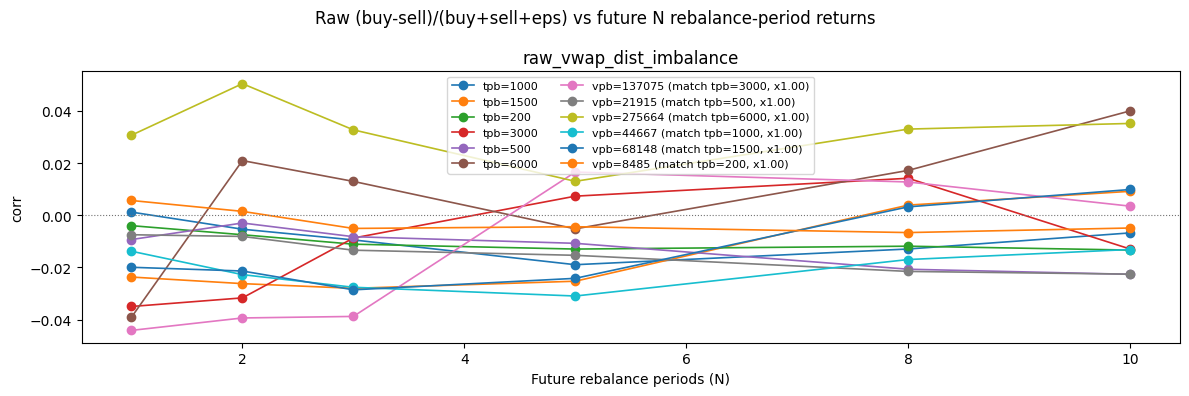

In [14]:
import matplotlib.pyplot as plt

# 默认只画：所有 tpb + scale≈1.0 的 matched volume bar（避免 float 与 NaN 误判）
_scale_ok = raw_signal_corr_grid["scale"].sub(1.0).abs() < 1e-6
plot_df = raw_signal_corr_grid[
    ((raw_signal_corr_grid["bar_mode"] == "trade_count") & (raw_signal_corr_grid["tpb"].isin(TPB_GRID)))
    | (
        (raw_signal_corr_grid["bar_mode"] == "volume")
        & (raw_signal_corr_grid["tpb_ref"].isin(TPB_GRID))
        & _scale_ok
    )
].copy()
print("plot_df labels:", sorted(plot_df["label"].unique()))

fig = plot_raw_signal_forward_corr_lines(
    plot_df,
    series_name="raw_vwap_dist_imbalance",
    title="Raw (buy-sell)/(buy+sell+eps) vs future N rebalance-period returns",
)
plt.show()

# 如需把全部 vpb candidates（含 0.75x / 1.25x）都画出来：
# fig = plot_raw_signal_forward_corr_lines(raw_signal_corr_grid)
# plt.show()

### 一阶差分 imbalance 与未来 N 个 rebalance period 收益的相关性

- **与上一节相同**：同一套 `bar_specs`（`tpb` + matched `vpb` / `scale`），同一 `FUTURE_HORIZONS`。
- **因子**：`Δimbalance_t = imbalance_t - imbalance_{t-1}`（`pandas.diff(1)`），与 `fwd_ret` 按索引对齐后算 Pearson 相关。
- **输出**：`raw_signal_d1_corr_grid` + 折线图（默认子集：全部 `tpb` + `scale≈1` 的 matched `vpb`，与上图一致）。
- **依赖**：先跑完构造 `bar_specs` 与 `raw_signal_corr_grid` 的 cell（本格复用 `bar_specs` / `TPB_GRID` / `FUTURE_HORIZONS`）。

Δimbalance corr rows by bar_mode:
bar_mode
trade_count     36
volume         108
dtype: int64


,bar_mode,tpb,vpb,series_name,horizon,corr,n_obs,n_bars,bar_dur_sec_med,factor_name,label,tpb_ref,scale
0,trade_count,200,0.0,d1_vwap_dist_imbalance,1,0.002053,19197,19199,137.02,Δ[(buy-sell)/(buy+sell+eps)],tpb=200,200,NaN
1,trade_count,200,0.0,d1_vwap_dist_imbalance,2,0.002591,19196,19199,137.02,Δ[(buy-sell)/(buy+sell+eps)],tpb=200,200,NaN
2,trade_count,200,0.0,d1_vwap_dist_imbalance,3,0.002600,19195,19199,137.02,Δ[(buy-sell)/(buy+sell+eps)],tpb=200,200,NaN
3,trade_count,200,0.0,d1_vwap_dist_imbalance,5,-0.003171,19193,19199,137.02,Δ[(buy-sell)/(buy+sell+eps)],tpb=200,200,NaN
4,trade_count,200,0.0,d1_vwap_dist_imbalance,8,0.001014,19190,19199,137.02,Δ[(buy-sell)/(buy+sell+eps)],tpb=200,200,NaN


,label,bar_mode,tpb,vpb,tpb_ref,scale,n_bars,bar_dur_sec_med,series_name,horizon,corr,n_obs
0,tpb=200,trade_count,200,0.0,200,NaN,19199,137.0200,d1_vwap_dist_imbalance,1,0.002053,19197
1,tpb=200,trade_count,200,0.0,200,NaN,19199,137.0200,d1_vwap_dist_imbalance,2,0.002591,19196
2,tpb=200,trade_count,200,0.0,200,NaN,19199,137.0200,d1_vwap_dist_imbalance,3,0.002600,19195
3,tpb=200,trade_count,200,0.0,200,NaN,19199,137.0200,d1_vwap_dist_imbalance,5,-0.003171,19193
4,tpb=200,trade_count,200,0.0,200,NaN,19199,137.0200,d1_vwap_dist_imbalance,8,0.001014,19190
5,tpb=200,trade_count,200,0.0,200,NaN,19199,137.0200,d1_vwap_dist_imbalance,10,-0.003963,19188
6,tpb=500,trade_count,500,0.0,500,NaN,7680,355.5000,d1_vwap_dist_imbalance,1,-0.011942,7678
7,tpb=500,trade_count,500,0.0,500,NaN,7680,355.5000,d1_vwap_dist_imbalance,2,0.000389,7677
8,tpb=500,trade_count,500,0.0,500,NaN,7680,355.5000,d1_vwap_dist_imbalance,3,-0.001691,7676
9,tpb=500,trade_count,500,0.0,500,NaN,7680,355.5000,d1_vwap_dist_imbalance,5,-0.005769,7674


,label,bar_mode,tpb,vpb,tpb_ref,scale,n_bars,bar_dur_sec_med,series_name,horizon,corr,n_obs
36,"vpb=6364 (match tpb=200, x0.75)",volume,200,6363.9075,200,0.75,27335,82.874,d1_vwap_dist_imbalance,1,0.003168,27333
37,"vpb=6364 (match tpb=200, x0.75)",volume,200,6363.9075,200,0.75,27335,82.874,d1_vwap_dist_imbalance,2,0.004576,27332
38,"vpb=6364 (match tpb=200, x0.75)",volume,200,6363.9075,200,0.75,27335,82.874,d1_vwap_dist_imbalance,3,0.005714,27331
39,"vpb=6364 (match tpb=200, x0.75)",volume,200,6363.9075,200,0.75,27335,82.874,d1_vwap_dist_imbalance,5,0.002894,27329
40,"vpb=6364 (match tpb=200, x0.75)",volume,200,6363.9075,200,0.75,27335,82.874,d1_vwap_dist_imbalance,8,0.002732,27326
...,...,...,...,...,...,...,...,...,...,...,...,...
139,"vpb=344580 (match tpb=6000, x1.25)",volume,6000,344580.5000,6000,1.25,527,5968.145,d1_vwap_dist_imbalance,2,-0.007907,524
140,"vpb=344580 (match tpb=6000, x1.25)",volume,6000,344580.5000,6000,1.25,527,5968.145,d1_vwap_dist_imbalance,3,-0.008966,523
141,"vpb=344580 (match tpb=6000, x1.25)",volume,6000,344580.5000,6000,1.25,527,5968.145,d1_vwap_dist_imbalance,5,-0.011693,521
142,"vpb=344580 (match tpb=6000, x1.25)",volume,6000,344580.5000,6000,1.25,527,5968.145,d1_vwap_dist_imbalance,8,-0.015632,518


plot_df_d1 labels: ['tpb=1000', 'tpb=1500', 'tpb=200', 'tpb=3000', 'tpb=500', 'tpb=6000', 'vpb=137075 (match tpb=3000, x1.00)', 'vpb=21915 (match tpb=500, x1.00)', 'vpb=275664 (match tpb=6000, x1.00)', 'vpb=44667 (match tpb=1000, x1.00)', 'vpb=68148 (match tpb=1500, x1.00)', 'vpb=8485 (match tpb=200, x1.00)']


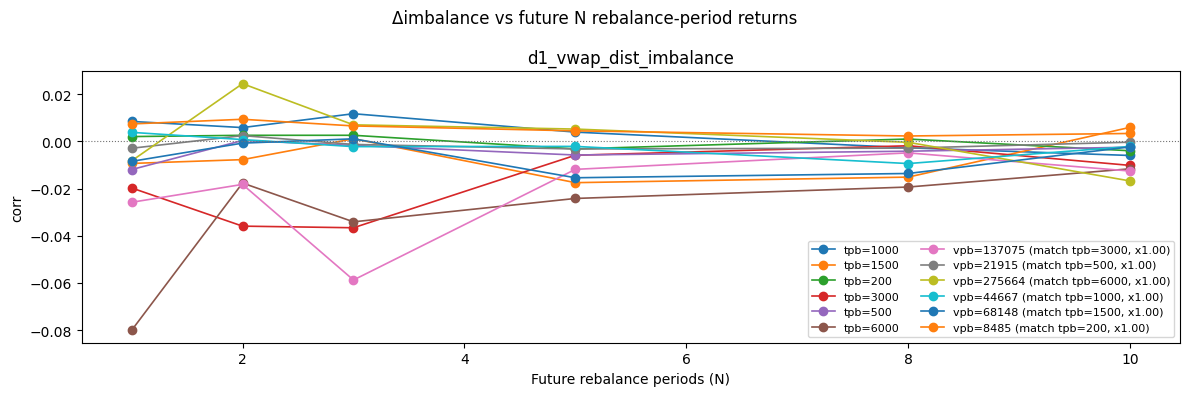

In [15]:
import matplotlib.pyplot as plt

_merged_d1 = globals().get("trades_df_full", globals().get("trades_df"))
if _merged_d1 is None:
    raise RuntimeError("需要 trades_df_full 或 trades_df")
if "bar_specs" not in globals():
    raise RuntimeError("先运行构造 bar_specs 的 cell")

corr_frames_d1 = []
for spec in bar_specs:
    spec_in = {
        "bar_mode": spec["bar_mode"],
        "tpb": int(spec["tpb"]),
        "vpb": float(spec["vpb"]),
    }
    corr_df, _bars_spec = evaluate_raw_signal_forward_corr(
        _merged_d1,
        spec_in,
        horizons=FUTURE_HORIZONS,
        imbalance_diff=1,
    )
    if corr_df.empty:
        continue
    corr_df["label"] = spec["label"]
    corr_df["tpb_ref"] = spec["tpb_ref"]
    corr_df["scale"] = spec["scale"]
    corr_frames_d1.append(corr_df)

raw_signal_d1_corr_grid = pd.concat(corr_frames_d1, ignore_index=True)

_cols_d1 = [
    "label", "bar_mode", "tpb", "vpb", "tpb_ref", "scale",
    "n_bars", "bar_dur_sec_med", "series_name", "horizon", "corr", "n_obs",
]
print("Δimbalance corr rows by bar_mode:")
print(raw_signal_d1_corr_grid.groupby("bar_mode", dropna=False).size())
display(raw_signal_d1_corr_grid.head())
display(
    raw_signal_d1_corr_grid.loc[raw_signal_d1_corr_grid["bar_mode"] == "trade_count", _cols_d1].sort_values(
        ["tpb", "horizon"]
    )
)
display(
    raw_signal_d1_corr_grid.loc[raw_signal_d1_corr_grid["bar_mode"] == "volume", _cols_d1].sort_values(
        ["tpb_ref", "scale", "horizon"]
    )
)

_scale_ok_d1 = raw_signal_d1_corr_grid["scale"].sub(1.0).abs() < 1e-6
plot_df_d1 = raw_signal_d1_corr_grid[
    ((raw_signal_d1_corr_grid["bar_mode"] == "trade_count") & (raw_signal_d1_corr_grid["tpb"].isin(TPB_GRID)))
    | (
        (raw_signal_d1_corr_grid["bar_mode"] == "volume")
        & (raw_signal_d1_corr_grid["tpb_ref"].isin(TPB_GRID))
        & _scale_ok_d1
    )
].copy()
print("plot_df_d1 labels:", sorted(plot_df_d1["label"].unique()))

fig_d1 = plot_raw_signal_forward_corr_lines(
    plot_df_d1,
    series_name="d1_vwap_dist_imbalance",
    title="Δimbalance vs future N rebalance-period returns",
)
plt.show()

### Imbalance **一阶差分** 的 Hurst（按 bar 聚合方式对照）

- **信号**：先算单根 bar 的 imbalance `(buy - sell) / (buy + sell + eps)`，再取 **一阶差分** `Δx_t = x_t - x_{t-1}`（丢掉首行 `NaN`）。
- **估计**：在 **Δimbalance** 序列上做多尺度 **R/S**（块内去均值 → 累积偏差 → R/S，`log(w)` 对 `log(mean R/S)` 回归斜率）。差分可削弱缓慢漂移、使过程更接近平稳增量，但**仍非**正式单位根检验；结果宜用于 **不同 bar 规格之间的横向对比**。
- **依赖**：须先跑完构造 **`bar_specs`** 的 cell，且内存里已有 **`trades_df_full`** 或 **`trades_df`**。

In [16]:
import numpy as np
import matplotlib.pyplot as plt


def estimate_hurst_rs(
    series: pd.Series,
    *,
    min_window: int = 64,
    n_window_grid: int = 22,
) -> tuple[float, pd.DataFrame]:
    """多尺度 R/S：块内去均值 → 累积偏差 → R/S；对 log(w)~log(R/S) 回归斜率。此处输入为 imbalance 的一阶差分。"""
    x = series.dropna().values.astype(float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < min_window * 6:
        return np.nan, pd.DataFrame()

    max_w = n // 6
    if max_w <= min_window:
        return np.nan, pd.DataFrame()

    windows = np.unique(
        np.linspace(min_window, max_w, num=min(n_window_grid, max_w - min_window + 1)).astype(int)
    )
    rows = []
    for w in windows:
        if w < min_window:
            continue
        k = n // w
        if k < 4:
            continue
        rs_list = []
        for j in range(k):
            seg = x[j * w : (j + 1) * w].copy()
            seg = seg - np.mean(seg)
            Z = np.cumsum(seg)
            R = float(Z.max() - Z.min())
            S = float(np.std(seg, ddof=1))
            if S > 1e-15 and R > 0:
                rs_list.append(R / S)
        if len(rs_list) < 3:
            continue
        rows.append({"window": int(w), "rs_mean": float(np.mean(rs_list))})

    dfw = pd.DataFrame(rows)
    if len(dfw) < 5 or (dfw["rs_mean"] <= 0).any():
        return np.nan, dfw

    log_w = np.log(dfw["window"].to_numpy(dtype=float))
    log_rs = np.log(dfw["rs_mean"].to_numpy(dtype=float))
    H_hat = float(np.polyfit(log_w, log_rs, 1)[0])
    return H_hat, dfw

,label,bar_mode,tpb,vpb,tpb_ref,scale,n_bars,bar_dur_sec_med,hurst_rs_on_d1_imbalance
0,tpb=200,trade_count,200,0.00000,200,NaN,19199,137.0200,0.083658
1,tpb=500,trade_count,500,0.00000,500,NaN,7680,355.5000,0.099582
2,tpb=1000,trade_count,1000,0.00000,1000,NaN,3840,733.2905,0.148318
3,tpb=1500,trade_count,1500,0.00000,1500,NaN,2560,1117.6915,0.161233
4,tpb=3000,trade_count,3000,0.00000,3000,NaN,1280,2277.9175,0.169693
5,tpb=6000,trade_count,6000,0.00000,6000,NaN,640,4625.9300,0.141212
6,"vpb=6364 (match tpb=200, x0.75)",volume,200,6363.90750,200,0.75,27335,82.8740,0.075005
7,"vpb=8485 (match tpb=200, x1.00)",volume,200,8485.21000,200,1.00,20709,112.5770,0.093171
8,"vpb=10607 (match tpb=200, x1.25)",volume,200,10606.51250,200,1.25,16659,143.4070,0.108213
9,"vpb=16436 (match tpb=500, x0.75)",volume,500,16436.46750,500,0.75,10849,227.7990,0.125497


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_18202/3103443967.py:51: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_18202/3103443967.py:51: UserWarning: Glyph 32771 (\N{CJK UNIFIED IDEOGRAPH-8003}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Users/quqiancheng/mean_reversion_cta_pm/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/quqiancheng/mean_reversion_cta_pm/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32771 (\N{CJK UNIFIED IDEOGRAPH-8003}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


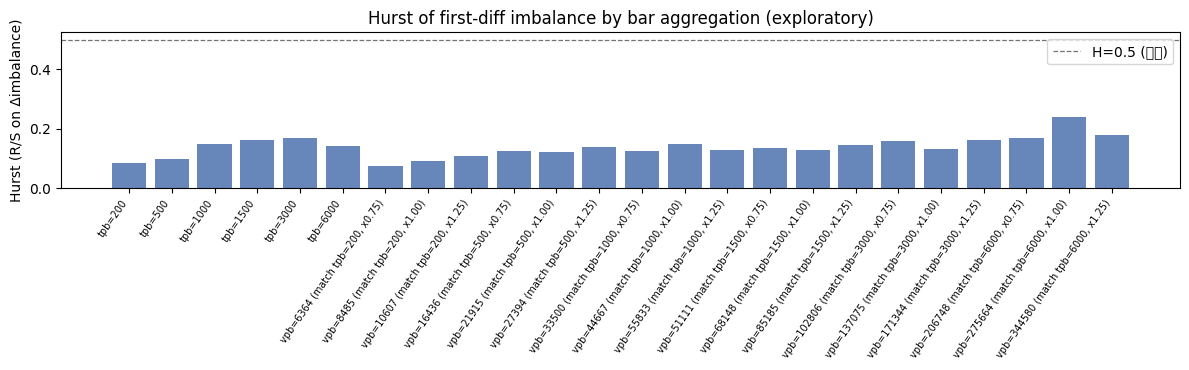

,label,bar_mode,tpb,vpb,tpb_ref,scale,n_bars,bar_dur_sec_med,hurst_rs_on_d1_imbalance
0,tpb=200,trade_count,200,0.000,200,NaN,19199,137.0200,0.083658
7,"vpb=8485 (match tpb=200, x1.00)",volume,200,8485.210,200,1.0,20709,112.5770,0.093171
1,tpb=500,trade_count,500,0.000,500,NaN,7680,355.5000,0.099582
10,"vpb=21915 (match tpb=500, x1.00)",volume,500,21915.290,500,1.0,8178,311.5000,0.123337
2,tpb=1000,trade_count,1000,0.000,1000,NaN,3840,733.2905,0.148318
13,"vpb=44667 (match tpb=1000, x1.00)",volume,1000,44666.745,1000,1.0,4037,671.4140,0.148135
3,tpb=1500,trade_count,1500,0.000,1500,NaN,2560,1117.6915,0.161233
16,"vpb=68148 (match tpb=1500, x1.00)",volume,1500,68148.375,1500,1.0,2652,1058.4990,0.127940
4,tpb=3000,trade_count,3000,0.000,3000,NaN,1280,2277.9175,0.169693
19,"vpb=137075 (match tpb=3000, x1.00)",volume,3000,137075.045,3000,1.0,1321,2214.9360,0.130925


In [17]:
_merged = globals().get("trades_df_full", globals().get("trades_df"))
if _merged is None:
    raise RuntimeError("需要先有 trades_df_full 或 trades_df（merged 成交）")

if "bar_specs" not in globals():
    raise RuntimeError("需要先运行构造 bar_specs 的 cell（与 raw_signal_corr_grid 同一格）")

hurst_rows = []
for spec in bar_specs:
    spec_in = {
        "bar_mode": spec["bar_mode"],
        "tpb": int(spec["tpb"]),
        "vpb": float(spec["vpb"]),
    }
    bars_h = build_merged_bars_from_spec(_merged, spec_in)
    if bars_h.empty or "buy_vwap_dist_sum" not in bars_h.columns:
        continue
    imb = raw_vwap_dist_sum_imbalance(bars_h)
    d_imb = imb.diff().dropna()
    H_hat, _diag = estimate_hurst_rs(d_imb)
    dur_med = float(bars_h["bar_duration_sec"].median()) if "bar_duration_sec" in bars_h.columns else np.nan
    hurst_rows.append(
        {
            "label": spec["label"],
            "bar_mode": spec["bar_mode"],
            "tpb": int(spec["tpb"]),
            "vpb": float(spec["vpb"]),
            "tpb_ref": spec.get("tpb_ref", spec["tpb"]),
            "scale": spec.get("scale", np.nan),
            "n_bars": len(bars_h),
            "bar_dur_sec_med": dur_med,
            "hurst_rs_on_d1_imbalance": H_hat,
        }
    )

imbalance_hurst_by_bar = pd.DataFrame(hurst_rows)
imbalance_hurst_by_bar = imbalance_hurst_by_bar.sort_values(
    ["bar_mode", "tpb_ref", "scale", "vpb"], na_position="last"
)
display(imbalance_hurst_by_bar)

fig, ax = plt.subplots(figsize=(12, 3.8))
xp = np.arange(len(imbalance_hurst_by_bar))
ax.bar(xp, imbalance_hurst_by_bar["hurst_rs_on_d1_imbalance"].values, color="#4c72b0", alpha=0.85)
ax.axhline(0.5, color="0.45", ls="--", lw=0.9, label="H=0.5 (参考)")
ax.set_xticks(xp)
ax.set_xticklabels(imbalance_hurst_by_bar["label"], rotation=55, ha="right", fontsize=7)
ax.set_ylabel("Hurst (R/S on Δimbalance)")
ax.set_title("Hurst of first-diff imbalance by bar aggregation (exploratory)")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

# 若只想对比「tpb 本档 + scale=1 的 matched vpb」，与上图 corr 默认子集对齐：
if "TPB_GRID" in globals() and "raw_signal_corr_grid" in globals():
    _s_ok = imbalance_hurst_by_bar["scale"].sub(1.0).abs() < 1e-6
    sub_h = imbalance_hurst_by_bar[
        (imbalance_hurst_by_bar["bar_mode"].eq("trade_count") & imbalance_hurst_by_bar["tpb"].isin(TPB_GRID))
        | (imbalance_hurst_by_bar["bar_mode"].eq("volume") & imbalance_hurst_by_bar["tpb_ref"].isin(TPB_GRID) & _s_ok)
    ]
    display(sub_h.sort_values(["tpb_ref", "bar_mode", "vpb"]))

### Rolling 去均值 imbalance：网格选窗 + 最优窗下的 IC 与 Hurst

**动机**：水平 imbalance 的 Hurst 常 &gt; 0.5；一阶差分的 Hurst 往往已经偏低，但与收益的 IC 会变弱（与价格的关系缺少逻辑支持）。Rolling demean 的目标是压低 **去均值后水平序列** 的 Hurst（更接近可均值回归的尺度）同时保留 IC。本节约在 **sig_dm** 水平上做 R/S，与 IC 联合选窗。

**流程**
1. **网格**：对每个 `bar_specs` 与一组 `ROLL_WINDOWS`（bar 根数，可改），构造 `sig_t = imb_t - mean(imb_{t-w+1..t})`。
2. **指标**：记录 `ic_h_opt`（在固定 horizon，默认 h=1 的原始有符号 IC）、`mean_abs_ic`（各 horizon 的 |corr| 均值，仅作参考）、`hurst_level_demeaned`（对 `sig_dm.dropna()` 做 R/S Hurst）。
3. **筛选规则**：先过滤 `hurst_level_demeaned &lt; 0.5` 且 `ic_h_opt &lt; 0` 的候选。
4. **选窗**：对每个 **`label`** 在候选中取 `ic_h_opt` **最小（最负）** 对应的 `rolling_w`。
5. **输出**：`rolling_demean_grid`（全网格）、`rolling_demean_candidates`（过滤后候选）、`rolling_demean_best_by_label`（最优行）、`rolling_demean_opt_ic`（最优窗下各 horizon 的 corr + Hurst）+ 默认子集折线图。

**依赖**：`d326b4f1`（bars/imb/fwd）、`bar_specs`、`FUTURE_HORIZONS`、**Hurst 格里的 `estimate_hurst_rs`**、`trades_df_full` 或 `trades_df`。

rolling demean grid rows: 311 valid rows: 300 hurst< 0.5 and ic_h_opt<0 candidates: 104 selected labels: 19


,label,bar_mode,tpb,vpb,tpb_ref,scale,rolling_w,ic_h_opt,mean_abs_ic,hurst_level_demeaned,n_bars,bar_dur_sec_med
26,tpb=1000,trade_count,1000,0.0,1000,NaN,8,0.006815,0.015003,0.189968,3840,733.2905
27,tpb=1000,trade_count,1000,0.0,1000,NaN,12,-0.000517,0.018511,0.210616,3840,733.2905
28,tpb=1000,trade_count,1000,0.0,1000,NaN,16,0.000294,0.011938,0.230547,3840,733.2905
29,tpb=1000,trade_count,1000,0.0,1000,NaN,24,0.001240,0.010987,0.263648,3840,733.2905
30,tpb=1000,trade_count,1000,0.0,1000,NaN,32,0.004031,0.007063,0.312634,3840,733.2905
31,tpb=1000,trade_count,1000,0.0,1000,NaN,48,0.000662,0.009793,0.386558,3840,733.2905
32,tpb=1000,trade_count,1000,0.0,1000,NaN,64,0.000203,0.012556,0.456758,3840,733.2905
33,tpb=1000,trade_count,1000,0.0,1000,NaN,96,0.000278,0.010339,0.553744,3840,733.2905
34,tpb=1000,trade_count,1000,0.0,1000,NaN,128,-0.000082,0.011039,0.607600,3840,733.2905
35,tpb=1000,trade_count,1000,0.0,1000,NaN,192,-0.002115,0.009866,0.677266,3840,733.2905


,label,bar_mode,tpb,vpb,tpb_ref,scale,rolling_w,ic_h_opt,mean_abs_ic,hurst_level_demeaned,n_bars,bar_dur_sec_med
8,tpb=200,trade_count,200,0.00000,200,NaN,128,-0.003970,0.010303,0.387383,19199,137.0200
17,tpb=500,trade_count,500,0.00000,500,NaN,32,-0.010139,0.012714,0.261806,7680,355.5000
27,tpb=1000,trade_count,1000,0.00000,1000,NaN,12,-0.000517,0.018511,0.210616,3840,733.2905
44,tpb=1500,trade_count,1500,0.00000,1500,NaN,48,-0.029033,0.022667,0.475750,2560,1117.6915
55,tpb=3000,trade_count,3000,0.00000,3000,NaN,24,-0.043020,0.021533,0.465137,1280,2277.9175
65,tpb=6000,trade_count,6000,0.00000,6000,NaN,8,-0.044881,0.019460,0.309205,640,4625.9300
134,"vpb=21915 (match tpb=500, x1.00)",volume,500,21915.29000,500,1.00,32,-0.008744,0.018226,0.279563,8178,311.5000
146,"vpb=27394 (match tpb=500, x1.25)",volume,500,27394.11250,500,1.25,24,-0.007334,0.022494,0.248784,6557,394.2270
159,"vpb=33500 (match tpb=1000, x0.75)",volume,1000,33500.05875,1000,0.75,24,-0.015020,0.028700,0.270702,5370,487.3835
175,"vpb=44667 (match tpb=1000, x1.00)",volume,1000,44666.74500,1000,1.00,64,-0.015842,0.027223,0.463904,4037,671.4140


horizon,1,2,3,5,8,10
label,,,,,,
tpb=1000,-0.000517,-0.010632,-0.018671,-0.032316,-0.027741,-0.021185
tpb=1500,-0.029033,-0.032800,-0.035806,-0.031504,-0.005145,0.001714
tpb=200,-0.003970,-0.007807,-0.011284,-0.013036,-0.012007,-0.013715
tpb=3000,-0.043020,-0.039218,-0.017012,-0.003623,-0.000343,-0.025978
tpb=500,-0.010139,-0.003033,-0.008623,-0.010836,-0.020500,-0.023151
tpb=6000,-0.044881,0.009726,-0.001839,-0.033048,-0.023650,0.003615
"vpb=102806 (match tpb=3000, x0.75)",-0.020768,-0.035849,-0.025941,-0.009431,-0.000679,0.002264
"vpb=137075 (match tpb=3000, x1.00)",-0.055102,-0.051582,-0.054250,-0.000113,-0.005500,-0.013612
"vpb=171344 (match tpb=3000, x1.25)",-0.016637,-0.010747,0.001396,0.009390,-0.009499,-0.014475


,label,rolling_w_opt,hurst_level_demeaned
0,tpb=1000,12,0.210616
1,tpb=1500,48,0.475750
2,tpb=200,128,0.387383
3,tpb=3000,24,0.465137
4,tpb=500,32,0.261806
5,tpb=6000,8,0.309205
6,"vpb=102806 (match tpb=3000, x0.75)",32,0.465851
7,"vpb=137075 (match tpb=3000, x1.00)",24,0.454555
8,"vpb=171344 (match tpb=3000, x1.25)",16,0.443742
9,"vpb=206748 (match tpb=6000, x0.75)",8,0.319629


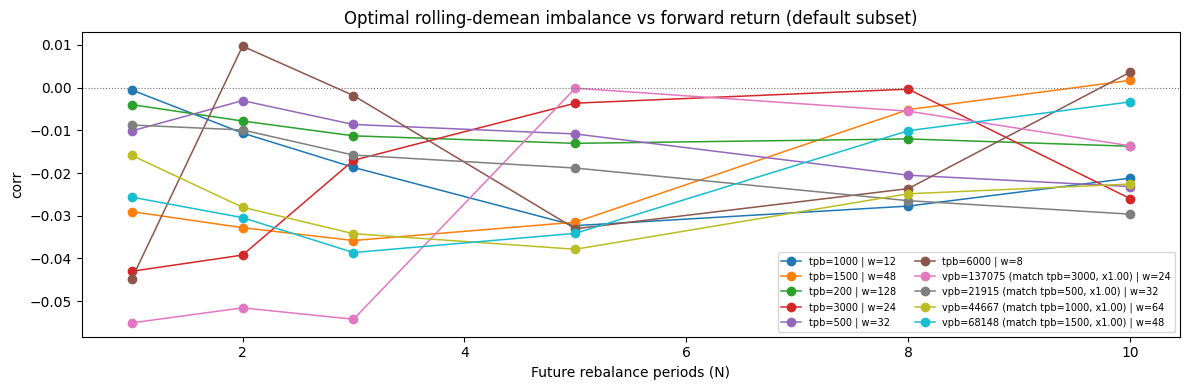

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "future_rebalance_return" not in globals() or "build_merged_bars_from_spec" not in globals():
    raise RuntimeError("先运行定义 future_rebalance_return / build_merged_bars_from_spec / raw_vwap_dist_sum_imbalance 的 cell")
if "estimate_hurst_rs" not in globals():
    raise RuntimeError("先运行 Hurst 一节中的 estimate_hurst_rs")
if "bar_specs" not in globals():
    raise RuntimeError("先运行构造 bar_specs 的 cell")

_merged_rd = globals().get("trades_df_full", globals().get("trades_df"))
if _merged_rd is None:
    raise RuntimeError("需要 trades_df_full 或 trades_df")

# --- 可调：窗口网格与筛选阈值 ---
ROLL_WINDOWS = [8, 12, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512]
IC_H_FOR_OPT = 1
HURST_MAX_FOR_OPT = 0.5
MIN_TAIL_BARS = 80
_horizons = list(FUTURE_HORIZONS) if "FUTURE_HORIZONS" in globals() else [1, 2, 3, 5, 8, 10]
_min_obs_ic = 200


def rolling_demean_series(s: pd.Series, window: int) -> pd.Series:
    w = int(window)
    return s - s.rolling(w, min_periods=w).mean()


def mean_abs_ic_vs_forward(sig: pd.Series, close: pd.Series, horizons, min_obs: int):
    corrs = []
    for h in horizons:
        fwd = future_rebalance_return(close, int(h))
        xy = pd.concat([sig.rename("f"), fwd.rename("r")], axis=1).dropna()
        if len(xy) < min_obs:
            corrs.append(np.nan)
        else:
            corrs.append(float(xy["f"].corr(xy["r"])))
    mabs = float(np.nanmean(np.abs(corrs))) if not all(np.isnan(corrs)) else np.nan
    return mabs, corrs


def ic_stability_halves(sig: pd.Series, close: pd.Series, horizon: int, min_obs: int):
    n = len(sig)
    mid = n // 2
    s1, c1 = sig.iloc[:mid], close.iloc[:mid]
    s2, c2 = sig.iloc[mid:], close.iloc[mid:]

    def _ic(sx, cx):
        fwd = future_rebalance_return(cx, int(horizon))
        xy = pd.concat([sx.rename("f"), fwd.rename("r")], axis=1).dropna()
        if len(xy) < min_obs:
            return np.nan
        return float(xy["f"].corr(xy["r"]))

    ic1, ic2 = _ic(s1, c1), _ic(s2, c2)
    if np.isnan(ic1) or np.isnan(ic2):
        return np.nan, ic1, ic2
    return abs(ic1 - ic2), ic1, ic2


spec_by_label = {s["label"]: s for s in bar_specs}
grid_rows = []

for spec in bar_specs:
    spec_in = {"bar_mode": spec["bar_mode"], "tpb": int(spec["tpb"]), "vpb": float(spec["vpb"])}
    bars_b = build_merged_bars_from_spec(_merged_rd, spec_in)
    if bars_b.empty:
        continue
    imb = raw_vwap_dist_sum_imbalance(bars_b)
    close = bars_b["close"]
    nbar = len(bars_b)
    dur_med = float(bars_b["bar_duration_sec"].median()) if "bar_duration_sec" in bars_b.columns else np.nan
    label = spec["label"]

    for w in ROLL_WINDOWS:
        if w >= nbar - MIN_TAIL_BARS:
            continue
        sig_dm = rolling_demean_series(imb, w)
        mabs_ic, _corrs = mean_abs_ic_vs_forward(sig_dm, close, _horizons, _min_obs_ic)

        fwd_opt = future_rebalance_return(close, int(IC_H_FOR_OPT))
        xy_opt = pd.concat([sig_dm.rename("f"), fwd_opt.rename("r")], axis=1).dropna()
        ic_h_opt = float(xy_opt["f"].corr(xy_opt["r"])) if len(xy_opt) >= _min_obs_ic else np.nan

        sig_dm_valid = sig_dm.dropna()
        H_lvl, _ = estimate_hurst_rs(sig_dm_valid)

        grid_rows.append(
            {
                "label": label,
                "bar_mode": spec["bar_mode"],
                "tpb": int(spec["tpb"]),
                "vpb": float(spec["vpb"]),
                "tpb_ref": spec.get("tpb_ref", spec["tpb"]),
                "scale": spec.get("scale", np.nan),
                "rolling_w": int(w),
                "ic_h_opt": ic_h_opt,
                "mean_abs_ic": mabs_ic,
                "hurst_level_demeaned": H_lvl,
                "n_bars": nbar,
                "bar_dur_sec_med": dur_med,
            }
        )

rolling_demean_grid = pd.DataFrame(grid_rows)
rolling_demean_grid_valid = rolling_demean_grid.dropna(subset=["ic_h_opt", "hurst_level_demeaned"]).copy()

# 新规则：每个 label 下，在 Hurst < 0.5 且 IC(指定 horizon) 为负的候选里，取 IC 最小（最负）对应的窗口
rolling_demean_candidates = rolling_demean_grid_valid[
    (rolling_demean_grid_valid["hurst_level_demeaned"] < HURST_MAX_FOR_OPT)
    & (rolling_demean_grid_valid["ic_h_opt"] < 0)
].copy()

rolling_demean_best_by_label = (
    rolling_demean_candidates.sort_values(["label", "ic_h_opt"], ascending=[True, True])
    .groupby("label", as_index=False)
    .head(1)
)

print(
    "rolling demean grid rows:",
    len(rolling_demean_grid),
    "valid rows:",
    len(rolling_demean_grid_valid),
    "hurst<",
    HURST_MAX_FOR_OPT,
    "and ic_h_opt<0 candidates:",
    len(rolling_demean_candidates),
    "selected labels:",
    rolling_demean_best_by_label["label"].nunique(),
)
display(rolling_demean_grid.sort_values(["label", "rolling_w"]).head(50))
display(
    rolling_demean_best_by_label.sort_values(["bar_mode", "tpb_ref", "scale"], na_position="last")
)

# 最优窗下：各 horizon 的 corr + 每个 label 的 Hurst（rolling 去均值后的**水平** sig_dm）
final_rows = []
for _, br in rolling_demean_best_by_label.iterrows():
    wopt = int(br["rolling_w"])
    label = br["label"]
    if label not in spec_by_label:
        continue
    spec = spec_by_label[label]
    spec_in = {"bar_mode": spec["bar_mode"], "tpb": int(spec["tpb"]), "vpb": float(spec["vpb"])}
    bars_b = build_merged_bars_from_spec(_merged_rd, spec_in)
    imb = raw_vwap_dist_sum_imbalance(bars_b)
    sig_dm = rolling_demean_series(imb, wopt)
    close = bars_b["close"]
    H_lvl, _ = estimate_hurst_rs(sig_dm.dropna())

    for h in _horizons:
        fwd = future_rebalance_return(close, int(h))
        xy = pd.concat([sig_dm.rename("f"), fwd.rename("r")], axis=1).dropna()
        corr = float(xy["f"].corr(xy["r"])) if len(xy) >= _min_obs_ic else np.nan
        final_rows.append(
            {
                "label": label,
                "rolling_w_opt": wopt,
                "horizon": int(h),
                "corr": corr,
                "n_obs": int(len(xy)),
                "hurst_level_demeaned": H_lvl,
            }
        )

rolling_demean_opt_ic = pd.DataFrame(final_rows)
_pivot = rolling_demean_opt_ic.pivot_table(index="label", columns="horizon", values="corr")
display(_pivot)
display(
    rolling_demean_opt_ic.groupby("label", as_index=False).agg(
        rolling_w_opt=("rolling_w_opt", "first"),
        hurst_level_demeaned=("hurst_level_demeaned", "first"),
    )
)

# 与 raw / d1 图同一默认子集：tpb 全 + scale≈1 的 matched vpb
if "TPB_GRID" in globals():
    _sok = rolling_demean_best_by_label["scale"].sub(1.0).abs() < 1e-6
    sub_best = rolling_demean_best_by_label[
        (rolling_demean_best_by_label["bar_mode"].eq("trade_count") & rolling_demean_best_by_label["tpb"].isin(TPB_GRID))
        | (
            rolling_demean_best_by_label["bar_mode"].eq("volume")
            & rolling_demean_best_by_label["tpb_ref"].isin(TPB_GRID)
            & _sok
        )
    ]
    try:
        apply_cta_matplotlib_style()
    except NameError:
        pass
    fig, ax = plt.subplots(figsize=(12, 4))
    for _, br in sub_best.iterrows():
        lbl = br["label"]
        wopt = int(br["rolling_w"])
        part = rolling_demean_opt_ic[rolling_demean_opt_ic["label"] == lbl].sort_values("horizon")
        ax.plot(part["horizon"], part["corr"], marker="o", lw=1.1, label=f"{lbl} | w={wopt}")
    ax.axhline(0, color="0.45", ls=":", lw=0.8)
    ax.set_xlabel("Future rebalance periods (N)")
    ax.set_ylabel("corr")
    ax.set_title("Optimal rolling-demean imbalance vs forward return (default subset)")
    ax.legend(fontsize=7, ncol=2, loc="best")
    fig.tight_layout()
    plt.show()


很明显，
原始信号的 hurst 在 0.5 - 0.7 之间，而 delta 虽然呈现hurst 更小，更满足均值回归，但与 return 的 IC 不如 signal，因为 delta 更大不能说明会反转，反而说明一方力量的强势，而且这个 signal 的趋势形成可能是 delta 先变大后变小的（delta 同向），因此不能直接用来做策略，缺乏逻辑；

但 raw signal 的 hurst > 0.5 还能用均值回归策略吗？

## 结论

用越短的 demean window 就越能排除趋势，长期window就于啥也没干（说明趋势周期都是较短的），因此应该固定 hurst level 小于某个 threshold 找到最佳 IC 配置参数；

### VPB参数稳定测试
测试 vpb 的稳定性，测试 vpb match 3000 左右的整数的 IC 稳定性

## MAE 与 MFE

最后一步确定是否适合做 minor pullback 
确定 mean reversion 的 entry z and exit z

In [19]:
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple, Optional, Sequence

def calculate_zscore(
    series: pd.Series,
    window: int = 100,
    method: str = 'zscore',        # 'zscore', 'mad'
    k: float = 2.0,
    vol_adjusted: bool = False,
    vol_series: Optional[pd.Series] = None,
    local_window: int = 10,
) -> pd.Series:
    """
    计算序列的标准化偏离（z-score 或 MAD 稳健版）
    返回的 zscore 是去中心化后的偏离程度（正值表示高于均值，负值表示低于均值）
    """
    # 滚动中心（均值或中位数）
    if method == 'zscore':
        rolling_center = series.rolling(window).mean()
        rolling_spread = series.rolling(window).std()
    elif method == 'mad':
        rolling_center = series.rolling(window).median()
        abs_dev = (series - rolling_center).abs()
        rolling_spread = abs_dev.rolling(window).median() * 1.4826  # 转为标准差尺度
    else:
        raise ValueError("method must be 'zscore' or 'mad'")

    # 计算原始偏离
    deviation = series - rolling_center
    zscore = deviation / (rolling_spread + 1e-10)

    # 成交量调整（可选项，调整后的阈值会乘上 sqrt(vol_ratio)）
    if vol_adjusted and vol_series is not None:
        local_vol = vol_series.rolling(local_window).mean()
        avg_vol = local_vol.rolling(window).mean()
        vol_factor = np.sqrt(local_vol / (avg_vol + 1e-10))
        # 注意：这里将 zscore 乘以成交量因子，相当于放宽阈值
        zscore = zscore * vol_factor

    return zscore.fillna(method='bfill').fillna(method='ffill')

# =============================================================================
# MAE / MFE & z-bucket diagnostics (mean reversion feasibility)
# =============================================================================


def rolling_demean_signal_mae(s: pd.Series, window: int) -> pd.Series:
    w = int(window)
    return s - s.rolling(w, min_periods=w).mean()


def pick_matched_volume_spec(
    bar_specs: Sequence[dict],
    *,
    tpb_ref: int = 3000,
    scale: float = 1.0,
) -> Optional[dict]:
    for s in bar_specs:
        if s.get("bar_mode") != "volume":
            continue
        if int(s.get("tpb_ref", -1)) != int(tpb_ref):
            continue
        sc = s.get("scale", np.nan)
        if pd.isna(sc) or abs(float(sc) - float(scale)) > 1e-6:
            continue
        return s
    return None


def build_mreversion_zscore_frame(
    bars: pd.DataFrame,
    *,
    demean_window: int,
    detrend_window: int,
    z_method: str = "zscore",
) -> pd.DataFrame:
    imb = raw_vwap_dist_sum_imbalance(bars)
    sig_dm = rolling_demean_signal_mae(imb, demean_window)
    z = calculate_zscore(sig_dm, window=int(detrend_window), method=z_method)
    out = bars.loc[:, ["open", "high", "low", "close"]].copy()
    out["imb_raw"] = imb
    out["sig_dm"] = sig_dm
    out["zscore"] = z
    return out


def _path_mfe_mae_ret_z(df: pd.DataFrame, i: int, side: int, H: int):
    """Entry at open[i]; scan bars i..i+H (inclusive). side: +1 long, -1 short."""
    o = float(df["open"].iloc[i])
    wdf = df.iloc[i : i + H + 1]
    hi = float(wdf["high"].max())
    lo = float(wdf["low"].min())
    c_end = float(df["close"].iloc[i + H])
    zpath = df["zscore"].iloc[i : i + H + 1].to_numpy(dtype=float)
    z0 = float(df["zscore"].iloc[i])
    z1 = float(df["zscore"].iloc[i + H])

    if side == 1:
        mfe = (hi - o) / o
        mae = (o - lo) / o
        ret_h = (c_end - o) / o
    elif side == -1:
        mfe = (o - lo) / o
        mae = (hi - o) / o
        ret_h = (o - c_end) / o
    else:
        raise ValueError("side must be +/-1")

    z_delta = z1 - z0
    z_mean_window = float(np.nanmean(zpath))
    return mfe, mae, ret_h, z_delta, z_mean_window


def _subsample_indices(idx: np.ndarray, max_signals: Optional[int], rng: np.random.Generator) -> np.ndarray:
    idx = np.asarray(idx, dtype=int)
    if max_signals is not None and len(idx) > max_signals:
        return rng.choice(idx, size=max_signals, replace=False)
    return idx


def mae_mfe_by_entry_threshold(
    df: pd.DataFrame,
    *,
    entry_z_long: Sequence[float],
    entry_z_short: Sequence[float],
    horizon_long: int,
    horizon_short: int,
    max_signals_per_side: Optional[int] = 50_000,
    random_state: int = 0,
) -> pd.DataFrame:
    """Long / short 使用各自的 entry 阈值网格与持有 horizon（bar 数）。"""
    rows: list = []
    zv = df["zscore"].to_numpy(dtype=float)
    n = len(df)
    HL = int(horizon_long)
    HS = int(horizon_short)

    def _collect(entry_list: Sequence[float], side: int, name: str, H: int, rs_off: int):
        rng = np.random.default_rng(random_state + rs_off)
        for ez in entry_list:
            ez = float(ez)
            idx = np.where(zv < -ez)[0] if side == 1 else np.where(zv > ez)[0]
            idx = idx[(idx >= 0) & (idx + H < n)]
            idx = idx[np.isfinite(zv[idx])]
            idx = _subsample_indices(idx, max_signals_per_side, rng)
            if len(idx) == 0:
                rows.append(
                    {
                        "side": name,
                        "entry_z": ez,
                        "horizon": int(H),
                        "n": 0,
                        "mfe_mean": np.nan,
                        "mfe_median": np.nan,
                        "mae_mean": np.nan,
                        "mae_median": np.nan,
                        "ret_h_mean": np.nan,
                        "ret_h_median": np.nan,
                        "z_delta_mean": np.nan,
                        "z_delta_median": np.nan,
                        "z_mean_in_window_mean": np.nan,
                        "z_mean_in_window_median": np.nan,
                    }
                )
                continue
            mfes, maes, rets, zds, zmw = [], [], [], [], []
            for i in idx:
                mfe, mae, ret_h, zd, zm = _path_mfe_mae_ret_z(df, int(i), side, H)
                mfes.append(mfe)
                maes.append(mae)
                rets.append(ret_h)
                zds.append(zd)
                zmw.append(zm)
            rows.append(
                {
                    "side": name,
                    "entry_z": ez,
                    "horizon": int(H),
                    "n": int(len(idx)),
                    "mfe_mean": float(np.mean(mfes)),
                    "mfe_median": float(np.median(mfes)),
                    "mae_mean": float(np.mean(maes)),
                    "mae_median": float(np.median(maes)),
                    "ret_h_mean": float(np.mean(rets)),
                    "ret_h_median": float(np.median(rets)),
                    "z_delta_mean": float(np.mean(zds)),
                    "z_delta_median": float(np.median(zds)),
                    "z_mean_in_window_mean": float(np.mean(zmw)),
                    "z_mean_in_window_median": float(np.median(zmw)),
                }
            )

    _collect(entry_z_long, 1, "long", HL, 0)
    _collect(entry_z_short, -1, "short", HS, 10_000)
    return pd.DataFrame(rows)


def mae_mfe_by_z_bucket(
    df: pd.DataFrame,
    *,
    bin_edges: Sequence[float],
    horizon_long: int,
    horizon_short: int,
    max_signals_per_bucket: Optional[int] = 30_000,
    random_state: int = 1,
) -> pd.DataFrame:
    """负 z 桶按 long horizon、正 z 桶按 short horizon（fade 方向与桶符号一致）。"""
    z = df["zscore"].replace([np.inf, -np.inf], np.nan)
    ok = z.notna()
    df2 = df.loc[ok].reset_index(drop=True)
    z = df2["zscore"].astype(float)
    n = len(df2)
    HL = int(horizon_long)
    HS = int(horizon_short)
    labels = pd.cut(z, bins=list(bin_edges), right=False, include_lowest=True)
    rng = np.random.default_rng(random_state)
    rows: list = []
    zv = z.to_numpy(dtype=float)
    for bucket in labels.cat.categories:
        mask = (labels == bucket).to_numpy()
        idx = np.where(mask)[0]
        idx = idx[np.isfinite(zv[idx])]
        if len(idx) == 0:
            rows.append({"z_bucket": str(bucket), "n": 0})
            continue
        if max_signals_per_bucket is not None and len(idx) > max_signals_per_bucket:
            idx = rng.choice(idx, size=max_signals_per_bucket, replace=False)
        mfes, maes, rets, zds, zmwm = [], [], [], [], []
        for i in idx:
            z0 = float(zv[i])
            if abs(z0) < 1e-12:
                continue
            side = 1 if z0 < 0 else -1
            H = HL if side == 1 else HS
            if int(i) + H >= n:
                continue
            mfe, mae, ret_h, zd, zm = _path_mfe_mae_ret_z(df2, int(i), side, H)
            mfes.append(mfe)
            maes.append(mae)
            rets.append(ret_h)
            zds.append(zd)
            zmwm.append(zm)
        rows.append(
            {
                "z_bucket": str(bucket),
                "n": int(len(mfes)),
                "mfe_mean": float(np.mean(mfes)) if mfes else np.nan,
                "mfe_median": float(np.median(mfes)) if mfes else np.nan,
                "mae_mean": float(np.mean(maes)) if maes else np.nan,
                "mae_median": float(np.median(maes)) if maes else np.nan,
                "ret_h_mean": float(np.mean(rets)) if rets else np.nan,
                "ret_h_median": float(np.median(rets)) if rets else np.nan,
                "z_delta_mean": float(np.mean(zds)) if zds else np.nan,
                "z_delta_median": float(np.median(zds)) if zds else np.nan,
                "z_mean_in_window_mean": float(np.mean(zmwm)) if zmwm else np.nan,
                "z_mean_in_window_median": float(np.median(zmwm)) if zmwm else np.nan,
            }
        )
    return pd.DataFrame(rows)


def hit_rate_entry_exit_grid(
    z: pd.Series,
    *,
    entry_z_long: Sequence[float],
    exit_z_long: Sequence[float],
    horizon_long: int,
    entry_z_short: Sequence[float],
    exit_z_short: Sequence[float],
    horizon_short: int,
) -> pd.DataFrame:
    """Long / short 各自 (entry_z, exit_z) 网格与 horizon；hit = 未来 1..H 内 z 进入 (-exit_z, exit_z)。"""
    zv = z.to_numpy(dtype=float)
    n = len(zv)
    HL = int(horizon_long)
    HS = int(horizon_short)
    rows: list = []
    if n <= max(HL, HS) + 1:
        return pd.DataFrame(rows)

    for ez in entry_z_long:
        ez = float(ez)
        for xz in exit_z_long:
            xz = float(xz)
            if xz >= ez:
                continue
            hits = tot = 0
            for i in range(n - HL - 1):
                z0 = zv[i]
                if not np.isfinite(z0) or z0 >= -ez:
                    continue
                path = zv[i + 1 : i + HL + 1]
                if len(path) != HL or not np.all(np.isfinite(path)):
                    continue
                tot += 1
                inside = (path > -xz) & (path < xz)
                hits += int(np.any(inside))
            rows.append(
                {
                    "side": "long",
                    "entry_z": ez,
                    "exit_z": xz,
                    "horizon": HL,
                    "hit_rate": hits / tot if tot else np.nan,
                    "n": tot,
                }
            )

    for ez in entry_z_short:
        ez = float(ez)
        for xz in exit_z_short:
            xz = float(xz)
            if xz >= ez:
                continue
            hits = tot = 0
            for i in range(n - HS - 1):
                z0 = zv[i]
                if not np.isfinite(z0) or z0 <= ez:
                    continue
                path = zv[i + 1 : i + HS + 1]
                if len(path) != HS or not np.all(np.isfinite(path)):
                    continue
                tot += 1
                inside = (path > -xz) & (path < xz)
                hits += int(np.any(inside))
            rows.append(
                {
                    "side": "short",
                    "entry_z": ez,
                    "exit_z": xz,
                    "horizon": HS,
                    "hit_rate": hits / tot if tot else np.nan,
                    "n": tot,
                }
            )

    return pd.DataFrame(rows)


def run_mae_mfe_diagnostic_block(
    *,
    trades_df=None,
    bar_specs=None,
    tpb_ref: int = 3000,
    vol_scale: float = 1.0,
    demean_window: int = 24,
    detrend_window: int = 100,
    horizon: int = 20,
    horizon_long: Optional[int] = None,
    horizon_short: Optional[int] = None,
    entry_z_grid: Optional[Sequence[float]] = None,
    entry_z_long: Optional[Sequence[float]] = None,
    entry_z_short: Optional[Sequence[float]] = None,
    exit_z_grid: Optional[Sequence[float]] = None,
    exit_z_long: Optional[Sequence[float]] = None,
    exit_z_short: Optional[Sequence[float]] = None,
    z_bucket_edges: Optional[Sequence[float]] = None,
    max_signals_per_side: Optional[int] = 50_000,
    verbose: bool = True,
):
    """
    仅做**信号质量检验**（不跑策略、不开平仓模拟）。

    默认：matched volume bar（tpb_ref=3000, scale=1.0），imbalance rolling demean=24，
    再对 demean 后的水平序列做 detrend_window 的 zscore（调用本 cell 内的 `calculate_zscore`）。

    Long / short 可分别指定 entry/exit 网格与 horizon；未指定时回退到共用的 entry_z_grid / exit_z_grid / horizon。
    """
    if trades_df is None:
        trades_df = globals().get("trades_df_full", globals().get("trades_df"))
    if trades_df is None:
        raise RuntimeError("需要 trades_df_full 或 trades_df")
    if bar_specs is None:
        bar_specs = globals().get("bar_specs")
    if not bar_specs:
        raise RuntimeError("需要 bar_specs（先运行构造 bar_specs 的 cell）")
    if "build_merged_bars_from_spec" not in globals():
        raise RuntimeError("需要 build_merged_bars_from_spec")

    spec = pick_matched_volume_spec(bar_specs, tpb_ref=tpb_ref, scale=vol_scale)
    if spec is None:
        raise RuntimeError(f"未找到 volume match spec: tpb_ref={tpb_ref}, scale={vol_scale}")

    spec_in = {"bar_mode": spec["bar_mode"], "tpb": int(spec["tpb"]), "vpb": float(spec["vpb"])}
    bars = build_merged_bars_from_spec(trades_df, spec_in)
    dfz = build_mreversion_zscore_frame(
        bars,
        demean_window=demean_window,
        detrend_window=detrend_window,
        z_method="zscore",
    ).reset_index(drop=True)

    if entry_z_grid is None:
        entry_z_grid = [1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
    if exit_z_grid is None:
        exit_z_grid = [0.2, 0.3, 0.4, 0.5, 0.65, 0.8, 1.0, 1.2]
    if z_bucket_edges is None:
        z_bucket_edges = [-10.0, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 10.0]

    _ezl = list(entry_z_long) if entry_z_long is not None else list(entry_z_grid)
    _ezs = list(entry_z_short) if entry_z_short is not None else list(entry_z_grid)
    _xzl = list(exit_z_long) if exit_z_long is not None else list(exit_z_grid)
    _xzs = list(exit_z_short) if exit_z_short is not None else list(exit_z_grid)
    _hl = int(horizon_long) if horizon_long is not None else int(horizon)
    _hs = int(horizon_short) if horizon_short is not None else int(horizon)

    if verbose:
        print(
            "MAE/MFE suite:",
            spec.get("label", spec_in),
            f"demean_w={demean_window}",
            f"detrend_z_w={detrend_window}",
            f"horizon_long={_hl}",
            f"horizon_short={_hs}",
            f"n_bars={len(dfz)}",
        )

    t_entry = mae_mfe_by_entry_threshold(
        dfz,
        entry_z_long=_ezl,
        entry_z_short=_ezs,
        horizon_long=_hl,
        horizon_short=_hs,
        max_signals_per_side=max_signals_per_side,
    )
    t_bucket = mae_mfe_by_z_bucket(
        dfz,
        bin_edges=z_bucket_edges,
        horizon_long=_hl,
        horizon_short=_hs,
    )
    t_hit = hit_rate_entry_exit_grid(
        dfz["zscore"],
        entry_z_long=_ezl,
        exit_z_long=_xzl,
        horizon_long=_hl,
        entry_z_short=_ezs,
        exit_z_short=_xzs,
        horizon_short=_hs,
    )
    return {
        "spec": spec,
        "bars": bars,
        "df_z": dfz,
        "by_entry_z": t_entry,
        "by_z_bucket": t_bucket,
        "hit_grid": t_hit,
    }


# 设为 False 可跳过自动跑表（仅保留函数定义）
_RUN_MAE_MFE_BLOCK = True
if _RUN_MAE_MFE_BLOCK:
    try:
        _mae_pack = run_mae_mfe_diagnostic_block()
        display(_mae_pack["by_entry_z"].sort_values(["side", "entry_z", "horizon"]))
        display(_mae_pack["by_z_bucket"])
        display(_mae_pack["hit_grid"].sort_values(["side", "entry_z", "exit_z"]))
    except Exception as _e:
        print("MAE/MFE 自动诊断跳过或未就绪:", repr(_e))


MAE/MFE suite: vpb=137075 (match tpb=3000, x1.00) demean_w=24 detrend_z_w=100 horizon_long=20 horizon_short=20 n_bars=1321


,side,entry_z,horizon,n,mfe_mean,mfe_median,mae_mean,mae_median,ret_h_mean,ret_h_median,z_delta_mean,z_delta_median,z_mean_in_window_mean,z_mean_in_window_median
0,long,1.00,20,187,0.021035,0.013186,0.037300,0.034945,-0.010850,-0.018433,1.601805,1.602994,-0.053398,-0.046258
1,long,1.25,20,124,0.019155,0.011301,0.039625,0.036699,-0.014634,-0.023033,1.813516,1.787909,-0.093598,-0.068994
2,long,1.50,20,85,0.018472,0.010076,0.039301,0.037037,-0.014652,-0.022686,1.943845,1.979958,-0.082267,-0.054987
3,long,1.75,20,51,0.018535,0.008527,0.040745,0.037037,-0.017466,-0.022686,2.047125,2.163490,-0.118614,-0.095391
4,long,2.00,20,25,0.021994,0.012797,0.036564,0.034945,-0.010976,-0.019608,2.258837,2.331170,-0.142396,-0.076295
5,long,2.25,20,14,0.018315,0.007670,0.035306,0.035569,-0.010500,-0.020887,2.465416,2.424790,-0.140181,-0.063752
6,long,2.50,20,6,0.010063,0.001320,0.045999,0.049847,-0.023616,-0.021240,2.886175,2.424790,-0.179520,-0.161414
7,long,2.75,20,3,0.000851,0.000853,0.056648,0.061625,-0.036259,-0.022871,3.229727,2.331170,-0.256266,-0.271618
8,long,3.00,20,1,0.001238,0.001238,0.032091,0.032091,-0.022871,-0.022871,2.331170,2.331170,-0.271618,-0.271618
9,short,1.00,20,189,0.026236,0.020856,0.039119,0.032939,-0.007001,-0.003980,-1.616380,-1.575462,0.050535,0.073778


,z_bucket,n,mfe_mean,mfe_median,mae_mean,mae_median,ret_h_mean,ret_h_median,z_delta_mean,z_delta_median,z_mean_in_window_mean,z_mean_in_window_median
0,"[-10.0, -3.0)",1,0.001238,0.001238,0.032091,0.032091,-0.022871,-0.022871,2.331170,2.331170,-0.271618,-0.271618
1,"[-3.0, -2.5)",5,0.011828,0.001401,0.048781,0.054426,-0.023765,-0.019608,2.997176,2.518411,-0.161100,-0.051209
2,"[-2.5, -2.0)",19,0.025762,0.016289,0.033584,0.031402,-0.006985,-0.001742,2.060730,1.857720,-0.130672,-0.076295
3,"[-2.0, -1.5)",60,0.017005,0.009635,0.040442,0.038106,-0.016184,-0.023879,1.812598,1.843982,-0.057214,-0.040475
4,"[-1.5, -1.0)",102,0.023170,0.017630,0.035632,0.032668,-0.007682,-0.013357,1.316771,1.266742,-0.029341,-0.044218
5,"[-1.0, -0.5)",185,0.028695,0.022698,0.033202,0.028410,-0.000644,-0.003322,0.854265,0.952258,-0.014770,-0.029176
6,"[-0.5, 0.0)",327,0.024048,0.018933,0.034240,0.031981,-0.009671,-0.012990,0.114997,0.000000,-0.071952,-0.141636
7,"[0.0, 0.5)",216,0.027262,0.022179,0.033887,0.026964,-0.003911,-0.001693,-0.199488,-0.107854,0.011725,0.013214
8,"[0.5, 1.0)",197,0.026887,0.020372,0.033712,0.026721,-0.003330,0.002174,-0.742326,-0.684580,0.049842,0.009392
9,"[1.0, 1.5)",118,0.024297,0.018981,0.040745,0.034917,-0.010475,-0.011482,-1.341485,-1.385739,0.062209,0.071380


,side,entry_z,exit_z,horizon,hit_rate,n
0,long,1.0,0.20,20,0.930481,187
1,long,1.0,0.30,20,0.989305,187
2,long,1.0,0.40,20,1.000000,187
3,long,1.0,0.50,20,1.000000,187
4,long,1.0,0.65,20,1.000000,187
...,...,...,...,...,...,...
135,short,3.0,0.50,20,1.000000,2
136,short,3.0,0.65,20,1.000000,2
137,short,3.0,0.80,20,1.000000,2
138,short,3.0,1.00,20,1.000000,2


,side,entry_z,horizon,n,ret_mean,ret_median,ret_win_rate,mfe_mean,mfe_median,mae_mean,mae_median
0,long,1.00,1,193,-0.007549,-0.007428,0.238342,0.003828,0.002828,0.014610,0.013807
1,long,1.00,2,193,-0.008005,-0.006651,0.274611,0.005110,0.003208,0.016865,0.015816
2,long,1.00,3,193,-0.007675,-0.007247,0.316062,0.006550,0.003878,0.018990,0.017303
3,long,1.00,5,193,-0.008886,-0.010436,0.295337,0.008927,0.005003,0.022165,0.019085
4,long,1.00,8,191,-0.008948,-0.009633,0.335079,0.011888,0.006971,0.025587,0.023012
5,long,1.00,10,190,-0.009456,-0.012752,0.368421,0.013697,0.009250,0.027624,0.025371
6,long,1.00,15,188,-0.011207,-0.015519,0.319149,0.017533,0.010839,0.032686,0.030600
7,long,1.00,20,187,-0.010850,-0.018433,0.315508,0.021035,0.013186,0.037300,0.034945
8,long,1.00,30,186,-0.011512,-0.018876,0.327957,0.027975,0.019093,0.045794,0.042013
9,long,1.00,40,184,-0.009553,-0.012435,0.396739,0.033051,0.022696,0.052472,0.047404


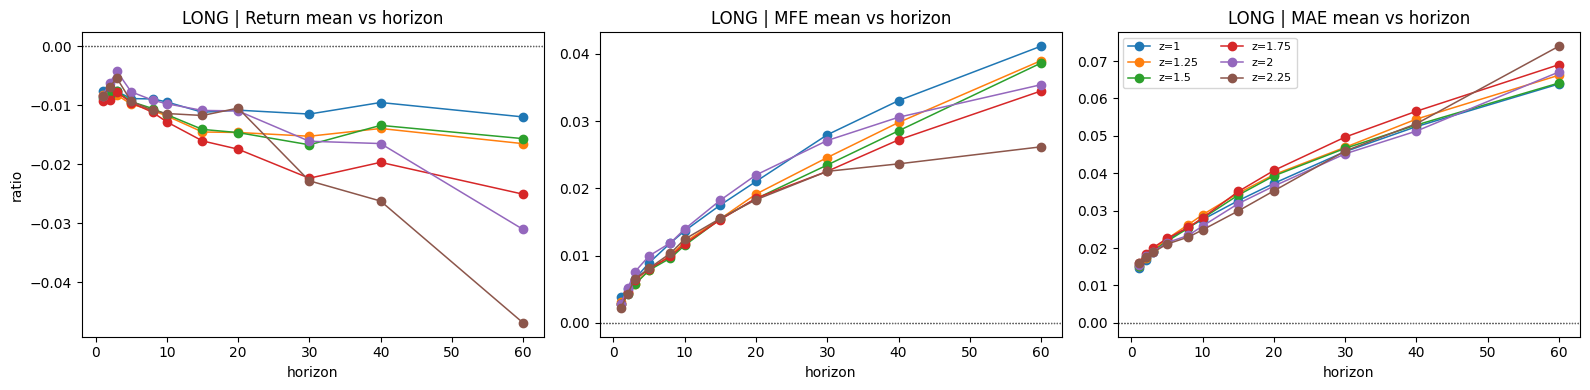

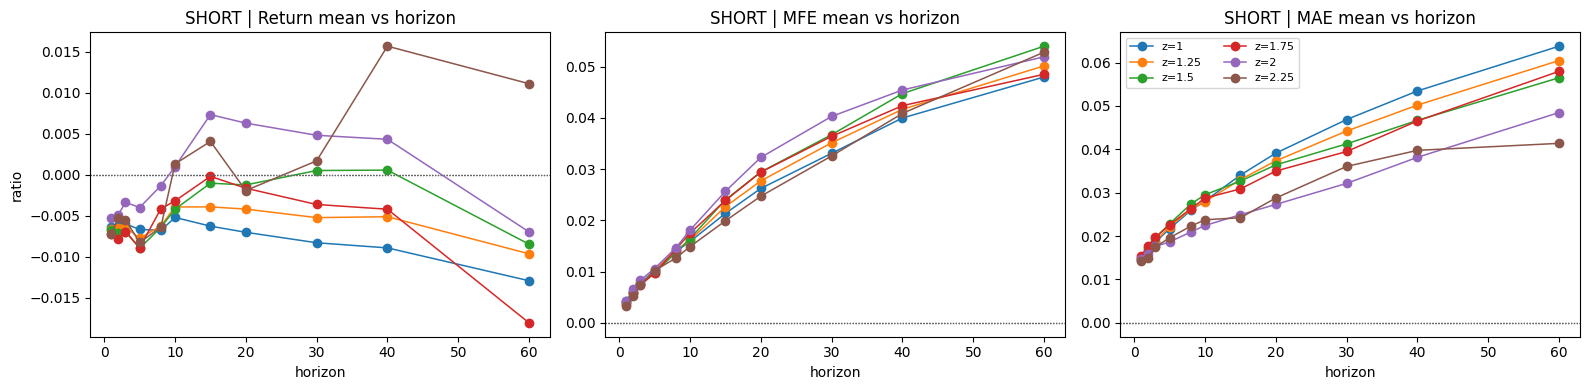

,side,entry_z,exit_z,max_h,n,hit_rate,ttr_mean,ttr_median,ttr_p75,ret_at_exit_mean,ret_at_exit_median,ret_at_exit_win_rate,ret_at_max_h_mean,ret_at_max_h_median
0,long,1.0,0.20,60,181,1.0,7.497238,5.0,10.00,-0.010343,-0.010516,0.298343,-0.011997,-0.013574
1,long,1.0,0.30,60,181,1.0,4.977901,4.0,7.00,-0.009608,-0.007945,0.314917,-0.011997,-0.013574
2,long,1.0,0.40,60,181,1.0,3.839779,3.0,5.00,-0.007128,-0.007010,0.309392,-0.011997,-0.013574
3,long,1.0,0.50,60,181,1.0,3.071823,2.0,4.00,-0.006814,-0.006765,0.298343,-0.011997,-0.013574
4,long,1.0,0.65,60,181,1.0,2.281768,2.0,3.00,-0.007439,-0.006855,0.276243,-0.011997,-0.013574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,short,3.0,0.50,60,2,1.0,9.000000,9.0,9.50,0.001163,0.001163,0.500000,0.050673,0.050673
136,short,3.0,0.65,60,2,1.0,4.000000,4.0,5.50,-0.016299,-0.016299,0.000000,0.050673,0.050673
137,short,3.0,0.80,60,2,1.0,2.000000,2.0,2.50,-0.011864,-0.011864,0.000000,0.050673,0.050673
138,short,3.0,1.00,60,2,1.0,2.000000,2.0,2.50,-0.011864,-0.011864,0.000000,0.050673,0.050673


stable candidates (n>=30): 0


,side,entry_z,exit_z,max_h,n,hit_rate,ttr_mean,ttr_median,ttr_p75,ret_at_exit_mean,ret_at_exit_median,ret_at_exit_win_rate,ret_at_max_h_mean,ret_at_max_h_median


exit_z,0.20,0.30,0.40,0.50,0.65,0.80,1.00,1.20
entry_z,,,,,,,,
1.00,-0.010343,-0.009608,-0.007128,-0.006814,-0.007439,-0.007009,NaN,NaN
1.25,-0.012801,-0.010733,-0.007520,-0.007382,-0.007291,-0.007168,-0.007644,-0.007472
1.50,-0.012491,-0.010591,-0.008000,-0.007619,-0.007303,-0.007154,-0.007902,-0.007847
1.75,-0.012198,-0.010365,-0.007483,-0.007640,-0.006997,-0.007156,-0.007439,-0.007765


exit_z,0.20,0.30,0.40,0.50,0.65,0.80,1.00,1.20
entry_z,,,,,,,,
1.00,-0.007177,-0.004708,-0.006823,-0.006916,-0.006524,-0.006839,NaN,NaN
1.25,-0.006114,-0.005383,-0.007599,-0.007634,-0.007355,-0.007616,-0.006907,-0.006650
1.50,-0.003345,-0.004717,-0.007165,-0.007169,-0.006725,-0.006992,-0.006414,-0.006719
1.75,-0.002697,-0.004189,-0.008391,-0.007801,-0.007858,-0.007932,-0.006881,-0.007260


In [20]:
# --- Time-evolution diagnostics: return/MAE/MFE curves + time-to-revert by (entry, exit) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "_mae_pack" not in globals() or not isinstance(_mae_pack, dict):
    _mae_pack = run_mae_mfe_diagnostic_block()

dfz = _mae_pack["df_z"].copy().reset_index(drop=True)
if dfz.empty:
    raise RuntimeError("df_z is empty, run MAE/MFE block first")

zv = dfz["zscore"].to_numpy(dtype=float)
op = dfz["open"].to_numpy(dtype=float)
hi = dfz["high"].to_numpy(dtype=float)
lo = dfz["low"].to_numpy(dtype=float)
cl = dfz["close"].to_numpy(dtype=float)

# 1) 多 horizon 演进：在不同 entry_z 下，观察 ret / MFE / MAE 的随时间变化
HORIZONS = [1, 2, 3, 5, 8, 10, 15, 20, 30, 40, 60]
ENTRY_LONG = sorted(_mae_pack["by_entry_z"].query("side=='long'")["entry_z"].dropna().unique().tolist())
ENTRY_SHORT = sorted(_mae_pack["by_entry_z"].query("side=='short'")["entry_z"].dropna().unique().tolist())


def _sample_idx_for_entry(zarr: np.ndarray, side: str, entry_z: float, h: int) -> np.ndarray:
    n = len(zarr)
    if side == "long":
        idx = np.where(zarr < -float(entry_z))[0]
    elif side == "short":
        idx = np.where(zarr > float(entry_z))[0]
    else:
        raise ValueError(side)
    idx = idx[(idx >= 0) & (idx + int(h) < n)]
    idx = idx[np.isfinite(zarr[idx])]
    return idx


def _path_metrics_at_h(i: int, h: int, side: str):
    o = op[i]
    hh = np.max(hi[i : i + h + 1])
    ll = np.min(lo[i : i + h + 1])
    c = cl[i + h]
    if side == "long":
        ret_h = (c - o) / o
        mfe_h = (hh - o) / o
        mae_h = (o - ll) / o
    else:
        ret_h = (o - c) / o
        mfe_h = (o - ll) / o
        mae_h = (hh - o) / o
    return ret_h, mfe_h, mae_h


rows_evo = []
for side, entry_list in (("long", ENTRY_LONG), ("short", ENTRY_SHORT)):
    for ez in entry_list:
        for h in HORIZONS:
            idx = _sample_idx_for_entry(zv, side, ez, h)
            if len(idx) == 0:
                rows_evo.append(
                    {
                        "side": side,
                        "entry_z": float(ez),
                        "horizon": int(h),
                        "n": 0,
                        "ret_mean": np.nan,
                        "ret_median": np.nan,
                        "ret_win_rate": np.nan,
                        "mfe_mean": np.nan,
                        "mfe_median": np.nan,
                        "mae_mean": np.nan,
                        "mae_median": np.nan,
                    }
                )
                continue
            rets, mfes, maes = [], [], []
            for i in idx:
                r, f, a = _path_metrics_at_h(int(i), int(h), side)
                rets.append(r)
                mfes.append(f)
                maes.append(a)
            rets = np.asarray(rets)
            mfes = np.asarray(mfes)
            maes = np.asarray(maes)
            rows_evo.append(
                {
                    "side": side,
                    "entry_z": float(ez),
                    "horizon": int(h),
                    "n": int(len(idx)),
                    "ret_mean": float(np.mean(rets)),
                    "ret_median": float(np.median(rets)),
                    "ret_win_rate": float(np.mean(rets > 0)),
                    "mfe_mean": float(np.mean(mfes)),
                    "mfe_median": float(np.median(mfes)),
                    "mae_mean": float(np.mean(maes)),
                    "mae_median": float(np.median(maes)),
                }
            )

evolution_df = pd.DataFrame(rows_evo)
display(evolution_df.sort_values(["side", "entry_z", "horizon"]).head(60))


# 可视化：每个 side 画 3 张图（ret_mean / mfe_mean / mae_mean 随 horizon）
def _plot_evolution(evo_df: pd.DataFrame, side: str, min_n: int = 10):
    part = evo_df[evo_df["side"] == side].copy()
    if part.empty:
        return
    try:
        apply_cta_matplotlib_style()
    except NameError:
        pass
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
    metrics = ["ret_mean", "mfe_mean", "mae_mean"]
    titles = ["Return mean vs horizon", "MFE mean vs horizon", "MAE mean vs horizon"]

    for ez in sorted(part["entry_z"].dropna().unique()):
        pz = part[(part["entry_z"] == ez) & (part["n"] >= min_n)].sort_values("horizon")
        if pz.empty:
            continue
        for ax, m, t in zip(axes, metrics, titles):
            ax.plot(pz["horizon"], pz[m], marker="o", lw=1.1, label=f"z={ez:g}")
            ax.set_title(f"{side.upper()} | {t}")
            ax.axhline(0, color="0.4", ls=":", lw=0.8)
            ax.set_xlabel("horizon")
    axes[0].set_ylabel("ratio")
    axes[-1].legend(fontsize=8, ncol=2, loc="best")
    fig.tight_layout()
    plt.show()


_plot_evolution(evolution_df, "long")
_plot_evolution(evolution_df, "short")


# 2) (entry_z, exit_z) 组合：关注回归耗时分布 + 回归时收益（而非仅 hit）
MAX_H = max(HORIZONS)
EXIT_LONG = sorted(_mae_pack["hit_grid"].query("side=='long'")["exit_z"].dropna().unique().tolist())
EXIT_SHORT = sorted(_mae_pack["hit_grid"].query("side=='short'")["exit_z"].dropna().unique().tolist())


def _first_revert_tau(i: int, side: str, entry_z: float, exit_z: float, max_h: int):
    z0 = zv[i]
    if side == "long" and z0 >= -entry_z:
        return np.nan
    if side == "short" and z0 <= entry_z:
        return np.nan
    end = min(i + max_h, len(zv) - 1)
    if end <= i:
        return np.nan
    path = zv[i + 1 : end + 1]
    if len(path) == 0 or np.any(~np.isfinite(path)):
        return np.nan
    hit = np.where((path > -exit_z) & (path < exit_z))[0]
    if len(hit) == 0:
        return np.nan
    return int(hit[0] + 1)


def _ret_at_tau(i: int, tau: int, side: str):
    o = op[i]
    c = cl[i + tau]
    return (c - o) / o if side == "long" else (o - c) / o


rows_combo = []
for side, entries, exits in (("long", ENTRY_LONG, EXIT_LONG), ("short", ENTRY_SHORT, EXIT_SHORT)):
    for ez in entries:
        for xz in exits:
            if xz >= ez:
                continue
            idx = _sample_idx_for_entry(zv, side, ez, MAX_H)
            if len(idx) == 0:
                rows_combo.append(
                    {
                        "side": side,
                        "entry_z": float(ez),
                        "exit_z": float(xz),
                        "max_h": int(MAX_H),
                        "n": 0,
                        "hit_rate": np.nan,
                        "ttr_mean": np.nan,
                        "ttr_median": np.nan,
                        "ttr_p75": np.nan,
                        "ret_at_exit_mean": np.nan,
                        "ret_at_exit_median": np.nan,
                        "ret_at_exit_win_rate": np.nan,
                        "ret_at_max_h_mean": np.nan,
                        "ret_at_max_h_median": np.nan,
                    }
                )
                continue

            taus = []
            ret_exit = []
            ret_max_h = []
            for i in idx:
                tau = _first_revert_tau(int(i), side, float(ez), float(xz), int(MAX_H))
                taus.append(tau)
                ret_max_h.append(_ret_at_tau(int(i), int(MAX_H), side))
                if pd.notna(tau):
                    ret_exit.append(_ret_at_tau(int(i), int(tau), side))

            taus = np.asarray(taus, dtype=float)
            hit_mask = np.isfinite(taus)
            hit_n = int(np.sum(hit_mask))

            rows_combo.append(
                {
                    "side": side,
                    "entry_z": float(ez),
                    "exit_z": float(xz),
                    "max_h": int(MAX_H),
                    "n": int(len(idx)),
                    "hit_rate": float(hit_n / len(idx)) if len(idx) else np.nan,
                    "ttr_mean": float(np.nanmean(taus)) if hit_n else np.nan,
                    "ttr_median": float(np.nanmedian(taus)) if hit_n else np.nan,
                    "ttr_p75": float(np.nanpercentile(taus, 75)) if hit_n else np.nan,
                    "ret_at_exit_mean": float(np.mean(ret_exit)) if hit_n else np.nan,
                    "ret_at_exit_median": float(np.median(ret_exit)) if hit_n else np.nan,
                    "ret_at_exit_win_rate": float(np.mean(np.asarray(ret_exit) > 0)) if hit_n else np.nan,
                    "ret_at_max_h_mean": float(np.mean(ret_max_h)) if len(ret_max_h) else np.nan,
                    "ret_at_max_h_median": float(np.median(ret_max_h)) if len(ret_max_h) else np.nan,
                }
            )

combo_df = pd.DataFrame(rows_combo).sort_values(["side", "entry_z", "exit_z"])
display(combo_df)


# 3) 候选筛选：找“回归过程中更可能稳定盈利”的参数组合
MIN_N = 30
stable_candidates = combo_df[
    (combo_df["n"] >= MIN_N)
    & (combo_df["hit_rate"] >= 0.7)
    & (combo_df["ret_at_exit_mean"] > 0)
    & (combo_df["ret_at_exit_median"] > 0)
    & (combo_df["ret_at_exit_win_rate"] >= 0.55)
].sort_values(["side", "ret_at_exit_mean", "ret_at_exit_median"], ascending=[True, False, False])

print(f"stable candidates (n>={MIN_N}):", len(stable_candidates))
display(stable_candidates)


# 辅助可视化：按 side 给出 entry-exit 的收益热力图（ret_at_exit_mean）
for side in ["long", "short"]:
    p = combo_df[(combo_df["side"] == side) & (combo_df["n"] >= MIN_N)]
    if p.empty:
        continue
    pv = p.pivot_table(index="entry_z", columns="exit_z", values="ret_at_exit_mean")
    display(pv)


应该更高频，当前 bar = 3000 => 0.5h, 20 bars 就是 10h => 而数据就处在一个 bearish mkt regime; 

MAE/MFE suite: vpb=8485 (match tpb=200, x1.00) demean_w=24 detrend_z_w=100 horizon_long=20 horizon_short=20 n_bars=20709


,side,entry_z,horizon,n,ret_mean,ret_median,ret_win_rate,mfe_mean,mfe_median,mae_mean,mae_median
0,long,1.00,1,3266,-0.002014,-0.002019,0.216779,0.000907,0.000576,0.003579,0.003278
1,long,1.00,2,3266,-0.002044,-0.002085,0.268830,0.001282,0.000773,0.004223,0.003859
2,long,1.00,3,3265,-0.001988,-0.002060,0.303216,0.001651,0.000968,0.004716,0.004271
3,long,1.00,5,3264,-0.002013,-0.002059,0.331801,0.002289,0.001365,0.005533,0.005009
4,long,1.00,8,3264,-0.002005,-0.002084,0.366728,0.003123,0.002027,0.006521,0.005863
5,long,1.00,10,3262,-0.002069,-0.002175,0.376150,0.003604,0.002379,0.007096,0.006377
6,long,1.00,15,3260,-0.002163,-0.002143,0.397239,0.004685,0.003414,0.008311,0.007309
7,long,1.00,20,3260,-0.002106,-0.002063,0.414110,0.005581,0.004186,0.009340,0.008196
8,long,1.00,30,3260,-0.001984,-0.002132,0.425153,0.007144,0.005447,0.010994,0.009530
9,long,1.00,40,3259,-0.002097,-0.001823,0.436023,0.008504,0.006552,0.012341,0.010683


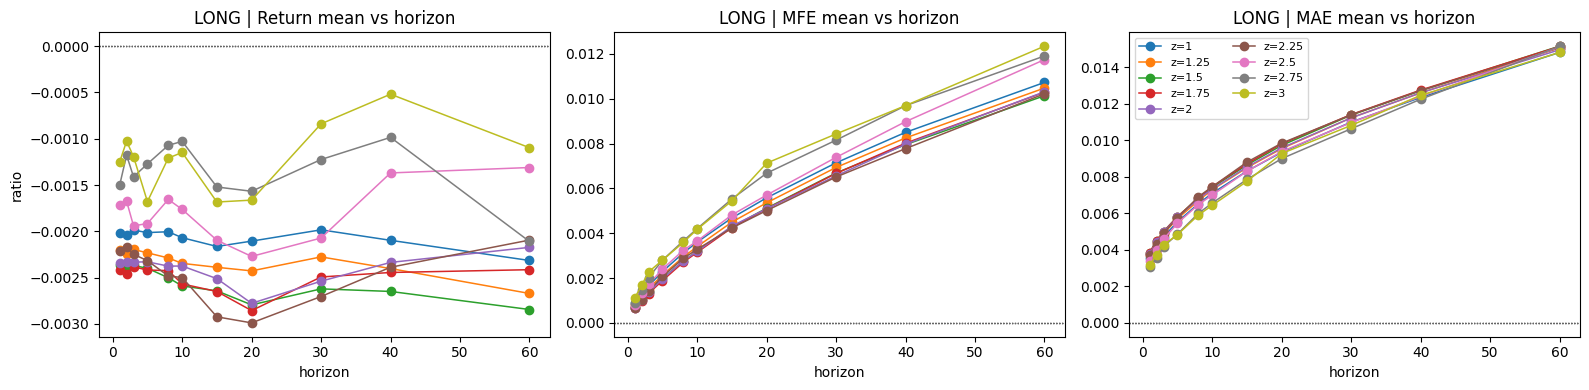

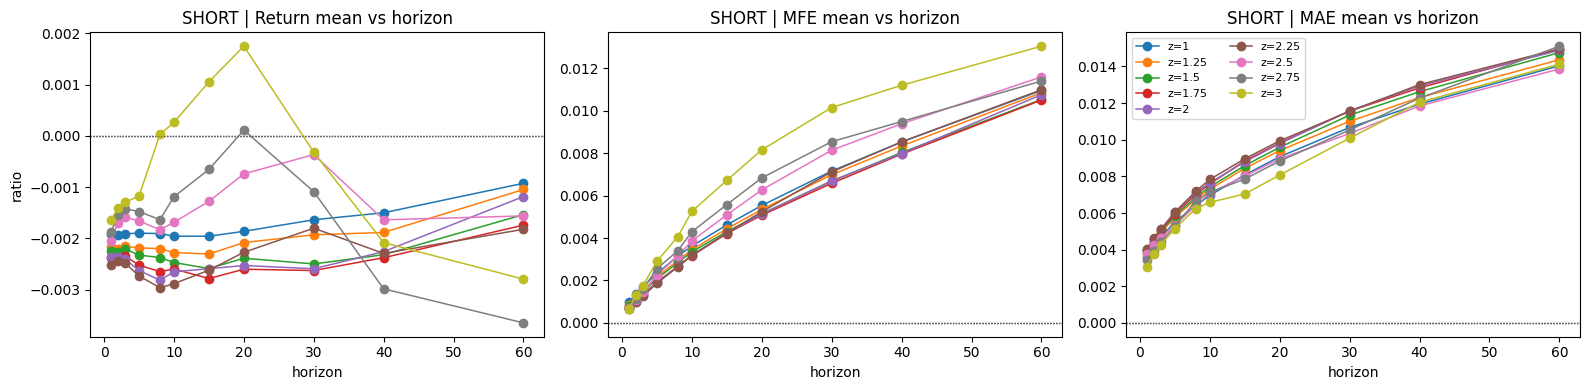

,side,entry_z,exit_z,max_h,n,hit_rate,ttr_mean,ttr_median,ttr_p75,ret_at_exit_mean,ret_at_exit_median,ret_at_exit_win_rate,ret_at_max_h_mean,ret_at_max_h_median
0,long,1.0,0.20,60,3253,1.0,6.454657,5.0,9.0,-0.001914,-0.001814,0.331694,-0.002315,-0.002086
1,long,1.0,0.30,60,3253,1.0,4.407316,3.0,6.0,-0.001881,-0.001872,0.302797,-0.002315,-0.002086
2,long,1.0,0.40,60,3253,1.0,3.430679,3.0,5.0,-0.001957,-0.001882,0.284353,-0.002315,-0.002086
3,long,1.0,0.50,60,3253,1.0,2.809714,2.0,4.0,-0.001962,-0.001908,0.269905,-0.002315,-0.002086
4,long,1.0,0.65,60,3253,1.0,2.197049,2.0,3.0,-0.001977,-0.001918,0.250845,-0.002315,-0.002086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,short,3.0,0.50,60,35,1.0,2.885714,2.0,4.0,-0.001560,-0.001917,0.342857,-0.002795,-0.005268
136,short,3.0,0.65,60,35,1.0,2.114286,2.0,2.5,-0.001861,-0.001917,0.257143,-0.002795,-0.005268
137,short,3.0,0.80,60,35,1.0,1.971429,1.0,2.0,-0.001744,-0.001752,0.228571,-0.002795,-0.005268
138,short,3.0,1.00,60,35,1.0,1.600000,1.0,2.0,-0.001698,-0.001752,0.171429,-0.002795,-0.005268


stable candidates (n>=30): 0


,side,entry_z,exit_z,max_h,n,hit_rate,ttr_mean,ttr_median,ttr_p75,ret_at_exit_mean,ret_at_exit_median,ret_at_exit_win_rate,ret_at_max_h_mean,ret_at_max_h_median


exit_z,0.20,0.30,0.40,0.50,0.65,0.80,1.00,1.20
entry_z,,,,,,,,
1.00,-0.001914,-0.001881,-0.001957,-0.001962,-0.001977,-0.002037,NaN,NaN
1.25,-0.002189,-0.002108,-0.002181,-0.002176,-0.002194,-0.002262,-0.002258,-0.002227
1.50,-0.002407,-0.002351,-0.002388,-0.002284,-0.002335,-0.002402,-0.002404,-0.002388
1.75,-0.002389,-0.002360,-0.002464,-0.002344,-0.002414,-0.002454,-0.002500,-0.002494
2.00,-0.002132,-0.002152,-0.002241,-0.002114,-0.002267,-0.002329,-0.002366,-0.002398
2.25,-0.002209,-0.002053,-0.002121,-0.001947,-0.002099,-0.002202,-0.002219,-0.002310
2.50,-0.001821,-0.001516,-0.001444,-0.001256,-0.001552,-0.001744,-0.001643,-0.001688
2.75,-0.000942,-0.000836,-0.000711,-0.000668,-0.001259,-0.001491,-0.001372,-0.001487
3.00,-0.001238,-0.000896,-0.000560,-0.000496,-0.000910,-0.000828,-0.000966,-0.001077


exit_z,0.20,0.30,0.40,0.50,0.65,0.80,1.00,1.20
entry_z,,,,,,,,
1.00,-0.002134,-0.002040,-0.002079,-0.002042,-0.002053,-0.002046,NaN,NaN
1.25,-0.002303,-0.002168,-0.002274,-0.002209,-0.002192,-0.002202,-0.002173,-0.002163
1.50,-0.002411,-0.002236,-0.002426,-0.002295,-0.002275,-0.002302,-0.002260,-0.002232
1.75,-0.002710,-0.002465,-0.002618,-0.002468,-0.002467,-0.002442,-0.002426,-0.002367
2.00,-0.002809,-0.002571,-0.002769,-0.002564,-0.002533,-0.002541,-0.002498,-0.002402
2.25,-0.003023,-0.002769,-0.003003,-0.002885,-0.002768,-0.002827,-0.002716,-0.002578
2.50,-0.002134,-0.002263,-0.002283,-0.002142,-0.002020,-0.002072,-0.001984,-0.001871
2.75,-0.002309,-0.002193,-0.002311,-0.002240,-0.002124,-0.002121,-0.002096,-0.001772
3.00,-0.001181,-0.001687,-0.001625,-0.001560,-0.001861,-0.001744,-0.001698,-0.001571


In [22]:
# --- Time-evolution diagnostics: return/MAE/MFE curves + time-to-revert by (entry, exit) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_mae_pack = run_mae_mfe_diagnostic_block(tpb_ref=200, vol_scale=1.0)

dfz = _mae_pack["df_z"].copy().reset_index(drop=True)
if dfz.empty:
    raise RuntimeError("df_z is empty, run MAE/MFE block first")

zv = dfz["zscore"].to_numpy(dtype=float)
op = dfz["open"].to_numpy(dtype=float)
hi = dfz["high"].to_numpy(dtype=float)
lo = dfz["low"].to_numpy(dtype=float)
cl = dfz["close"].to_numpy(dtype=float)

# 1) 多 horizon 演进：在不同 entry_z 下，观察 ret / MFE / MAE 的随时间变化
HORIZONS = [1, 2, 3, 5, 8, 10, 15, 20, 30, 40, 60]
ENTRY_LONG = sorted(_mae_pack["by_entry_z"].query("side=='long'")["entry_z"].dropna().unique().tolist())
ENTRY_SHORT = sorted(_mae_pack["by_entry_z"].query("side=='short'")["entry_z"].dropna().unique().tolist())


def _sample_idx_for_entry(zarr: np.ndarray, side: str, entry_z: float, h: int) -> np.ndarray:
    n = len(zarr)
    if side == "long":
        idx = np.where(zarr < -float(entry_z))[0]
    elif side == "short":
        idx = np.where(zarr > float(entry_z))[0]
    else:
        raise ValueError(side)
    idx = idx[(idx >= 0) & (idx + int(h) < n)]
    idx = idx[np.isfinite(zarr[idx])]
    return idx


def _path_metrics_at_h(i: int, h: int, side: str):
    o = op[i]
    hh = np.max(hi[i : i + h + 1])
    ll = np.min(lo[i : i + h + 1])
    c = cl[i + h]
    if side == "long":
        ret_h = (c - o) / o
        mfe_h = (hh - o) / o
        mae_h = (o - ll) / o
    else:
        ret_h = (o - c) / o
        mfe_h = (o - ll) / o
        mae_h = (hh - o) / o
    return ret_h, mfe_h, mae_h


rows_evo = []
for side, entry_list in (("long", ENTRY_LONG), ("short", ENTRY_SHORT)):
    for ez in entry_list:
        for h in HORIZONS:
            idx = _sample_idx_for_entry(zv, side, ez, h)
            if len(idx) == 0:
                rows_evo.append(
                    {
                        "side": side,
                        "entry_z": float(ez),
                        "horizon": int(h),
                        "n": 0,
                        "ret_mean": np.nan,
                        "ret_median": np.nan,
                        "ret_win_rate": np.nan,
                        "mfe_mean": np.nan,
                        "mfe_median": np.nan,
                        "mae_mean": np.nan,
                        "mae_median": np.nan,
                    }
                )
                continue
            rets, mfes, maes = [], [], []
            for i in idx:
                r, f, a = _path_metrics_at_h(int(i), int(h), side)
                rets.append(r)
                mfes.append(f)
                maes.append(a)
            rets = np.asarray(rets)
            mfes = np.asarray(mfes)
            maes = np.asarray(maes)
            rows_evo.append(
                {
                    "side": side,
                    "entry_z": float(ez),
                    "horizon": int(h),
                    "n": int(len(idx)),
                    "ret_mean": float(np.mean(rets)),
                    "ret_median": float(np.median(rets)),
                    "ret_win_rate": float(np.mean(rets > 0)),
                    "mfe_mean": float(np.mean(mfes)),
                    "mfe_median": float(np.median(mfes)),
                    "mae_mean": float(np.mean(maes)),
                    "mae_median": float(np.median(maes)),
                }
            )

evolution_df = pd.DataFrame(rows_evo)
display(evolution_df.sort_values(["side", "entry_z", "horizon"]).head(60))


# 可视化：每个 side 画 3 张图（ret_mean / mfe_mean / mae_mean 随 horizon）
def _plot_evolution(evo_df: pd.DataFrame, side: str, min_n: int = 10):
    part = evo_df[evo_df["side"] == side].copy()
    if part.empty:
        return
    try:
        apply_cta_matplotlib_style()
    except NameError:
        pass
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
    metrics = ["ret_mean", "mfe_mean", "mae_mean"]
    titles = ["Return mean vs horizon", "MFE mean vs horizon", "MAE mean vs horizon"]

    for ez in sorted(part["entry_z"].dropna().unique()):
        pz = part[(part["entry_z"] == ez) & (part["n"] >= min_n)].sort_values("horizon")
        if pz.empty:
            continue
        for ax, m, t in zip(axes, metrics, titles):
            ax.plot(pz["horizon"], pz[m], marker="o", lw=1.1, label=f"z={ez:g}")
            ax.set_title(f"{side.upper()} | {t}")
            ax.axhline(0, color="0.4", ls=":", lw=0.8)
            ax.set_xlabel("horizon")
    axes[0].set_ylabel("ratio")
    axes[-1].legend(fontsize=8, ncol=2, loc="best")
    fig.tight_layout()
    plt.show()


_plot_evolution(evolution_df, "long")
_plot_evolution(evolution_df, "short")


# 2) (entry_z, exit_z) 组合：关注回归耗时分布 + 回归时收益（而非仅 hit）
MAX_H = max(HORIZONS)
EXIT_LONG = sorted(_mae_pack["hit_grid"].query("side=='long'")["exit_z"].dropna().unique().tolist())
EXIT_SHORT = sorted(_mae_pack["hit_grid"].query("side=='short'")["exit_z"].dropna().unique().tolist())


def _first_revert_tau(i: int, side: str, entry_z: float, exit_z: float, max_h: int):
    z0 = zv[i]
    if side == "long" and z0 >= -entry_z:
        return np.nan
    if side == "short" and z0 <= entry_z:
        return np.nan
    end = min(i + max_h, len(zv) - 1)
    if end <= i:
        return np.nan
    path = zv[i + 1 : end + 1]
    if len(path) == 0 or np.any(~np.isfinite(path)):
        return np.nan
    hit = np.where((path > -exit_z) & (path < exit_z))[0]
    if len(hit) == 0:
        return np.nan
    return int(hit[0] + 1)


def _ret_at_tau(i: int, tau: int, side: str):
    o = op[i]
    c = cl[i + tau]
    return (c - o) / o if side == "long" else (o - c) / o


rows_combo = []
for side, entries, exits in (("long", ENTRY_LONG, EXIT_LONG), ("short", ENTRY_SHORT, EXIT_SHORT)):
    for ez in entries:
        for xz in exits:
            if xz >= ez:
                continue
            idx = _sample_idx_for_entry(zv, side, ez, MAX_H)
            if len(idx) == 0:
                rows_combo.append(
                    {
                        "side": side,
                        "entry_z": float(ez),
                        "exit_z": float(xz),
                        "max_h": int(MAX_H),
                        "n": 0,
                        "hit_rate": np.nan,
                        "ttr_mean": np.nan,
                        "ttr_median": np.nan,
                        "ttr_p75": np.nan,
                        "ret_at_exit_mean": np.nan,
                        "ret_at_exit_median": np.nan,
                        "ret_at_exit_win_rate": np.nan,
                        "ret_at_max_h_mean": np.nan,
                        "ret_at_max_h_median": np.nan,
                    }
                )
                continue

            taus = []
            ret_exit = []
            ret_max_h = []
            for i in idx:
                tau = _first_revert_tau(int(i), side, float(ez), float(xz), int(MAX_H))
                taus.append(tau)
                ret_max_h.append(_ret_at_tau(int(i), int(MAX_H), side))
                if pd.notna(tau):
                    ret_exit.append(_ret_at_tau(int(i), int(tau), side))

            taus = np.asarray(taus, dtype=float)
            hit_mask = np.isfinite(taus)
            hit_n = int(np.sum(hit_mask))

            rows_combo.append(
                {
                    "side": side,
                    "entry_z": float(ez),
                    "exit_z": float(xz),
                    "max_h": int(MAX_H),
                    "n": int(len(idx)),
                    "hit_rate": float(hit_n / len(idx)) if len(idx) else np.nan,
                    "ttr_mean": float(np.nanmean(taus)) if hit_n else np.nan,
                    "ttr_median": float(np.nanmedian(taus)) if hit_n else np.nan,
                    "ttr_p75": float(np.nanpercentile(taus, 75)) if hit_n else np.nan,
                    "ret_at_exit_mean": float(np.mean(ret_exit)) if hit_n else np.nan,
                    "ret_at_exit_median": float(np.median(ret_exit)) if hit_n else np.nan,
                    "ret_at_exit_win_rate": float(np.mean(np.asarray(ret_exit) > 0)) if hit_n else np.nan,
                    "ret_at_max_h_mean": float(np.mean(ret_max_h)) if len(ret_max_h) else np.nan,
                    "ret_at_max_h_median": float(np.median(ret_max_h)) if len(ret_max_h) else np.nan,
                }
            )

combo_df = pd.DataFrame(rows_combo).sort_values(["side", "entry_z", "exit_z"])
display(combo_df)


# 3) 候选筛选：找“回归过程中更可能稳定盈利”的参数组合
MIN_N = 30
stable_candidates = combo_df[
    (combo_df["n"] >= MIN_N)
    & (combo_df["hit_rate"] >= 0.7)
    & (combo_df["ret_at_exit_mean"] > 0)
    & (combo_df["ret_at_exit_median"] > 0)
    & (combo_df["ret_at_exit_win_rate"] >= 0.55)
].sort_values(["side", "ret_at_exit_mean", "ret_at_exit_median"], ascending=[True, False, False])

print(f"stable candidates (n>={MIN_N}):", len(stable_candidates))
display(stable_candidates)


# 辅助可视化：按 side 给出 entry-exit 的收益热力图（ret_at_exit_mean）
for side in ["long", "short"]:
    p = combo_df[(combo_df["side"] == side) & (combo_df["n"] >= MIN_N)]
    if p.empty:
        continue
    pv = p.pivot_table(index="entry_z", columns="exit_z", values="ret_at_exit_mean")
    display(pv)

In [ ]:
# Bar 设定：与 signal 扫描里「match tpb=3000, scale=1.0」一致 —— volume bar 目标量 = tpb=3000 每根 bar 成交量中位数 × 1
from rule_backtest.data_loader import build_trade_count_bars_merged, build_volume_bars_merged

MATCH_TPB = 3000
VPB_SCALE = 1.0
FW_V41 = 1
EMA_V41 = 1

_bars_tc_ref = build_trade_count_bars_merged(trades_df_full, MATCH_TPB)
VPB_MATCH = float(_bars_tc_ref["volume"].median()) * VPB_SCALE
print(
    f"match_tpb={MATCH_TPB}, vpb_scale={VPB_SCALE} -> VPB_MATCH={VPB_MATCH:,.4f}"
)

bars_v = build_volume_bars_merged(trades_df_full, VPB_MATCH)
FACTOR_COL = f"vwap_dist_sum_imbalance_mean_rev_v1"
bars_v[FACTOR_COL] = (bars_v['buy_vwap_dist_sum'] - bars_v['sell_vwap_dist_sum']) / (bars_v['buy_vwap_dist_sum'] + bars_v['sell_vwap_dist_sum'] + 1e-10)

bars_result, metrics, trades = mean_reversion_strategy(
    bars=bars_v,
    factor_col=FACTOR_COL,
    detrend_window=16,
    entry_z=2.0,
    exit_z=0.5,
    method='zscore',
    use_trend_filter=False, # 先看简单版
    adx_col='adx',          # 需要预先计算ADX和DI
    di_plus_col='plus_di',
    di_minus_col='minus_di',
    trend_adx_thresh=25.0,
    vol_adjusted=False,    # 已经按 volume 聚合 bar
    vol_series=bars_v['volume'],
    use_stops=False,   # 先看收益分布
    stop_atr_mult=2.0,
    stop_trailing=False,
    trail_atr_mult=3.0,
    max_holding_bars=20,
    factor_name='mean_rev_v1',
    metrics_fw=FW_V41,
    metrics_ema_w=float(EMA_V41),
)

In [ ]:
# Bar 设定：与 signal 扫描里「match tpb=3000, scale=1.0」一致 —— volume bar 目标量 = tpb=3000 每根 bar 成交量中位数 × 1
from rule_backtest.data_loader import build_trade_count_bars_merged, build_volume_bars_merged

MATCH_TPB = 3000
VPB_SCALE = 1.0
FW_V41 = 1
EMA_V41 = 1

_bars_tc_ref = build_trade_count_bars_merged(trades_df_full, MATCH_TPB)
VPB_MATCH = float(_bars_tc_ref["volume"].median()) * VPB_SCALE
print(
    f"match_tpb={MATCH_TPB}, vpb_scale={VPB_SCALE} -> VPB_MATCH={VPB_MATCH:,.4f}"
)

bars_v = build_volume_bars_merged(trades_df_full, VPB_MATCH)
FACTOR_COL = f"vwap_dist_sum_imbalance_mean_rev_v1"
bars_v[FACTOR_COL] = (bars_v['buy_vwap_dist_sum'] - bars_v['sell_vwap_dist_sum']) / (bars_v['buy_vwap_dist_sum'] + bars_v['sell_vwap_dist_sum'] + 1e-10)

bars_result, metrics, trades = mean_reversion_strategy(
    bars=bars_v,
    factor_col=FACTOR_COL,
    detrend_window=16,
    entry_z=2.0,
    exit_z=0.5,
    method='zscore',
    use_trend_filter=False, # 先看简单版
    adx_col='adx',          # 需要预先计算ADX和DI
    di_plus_col='plus_di',
    di_minus_col='minus_di',
    trend_adx_thresh=25.0,
    vol_adjusted=False,    # 已经按 volume 聚合 bar
    vol_series=bars_v['volume'],
    use_stops=False,   # 先看收益分布
    stop_atr_mult=2.0,
    stop_trailing=False,
    trail_atr_mult=3.0,
    max_holding_bars=20,
    factor_name='mean_rev_v1',
    metrics_fw=FW_V41,
    metrics_ema_w=float(EMA_V41),
)

## delta 换比值应该更合理，在 deep imbalance / minor imbalance 把 delta 进行逆转的难度是不一样的，deep imbalance 的时候必然惯性更强